In [20]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🏏 IPL Data Scientist Hiring

<div style="background-color: #1e3a8a; color: white; padding: 20px; border-radius: 10px;">
<h2>Position: Senior Data Scientist - IPL Analytics Team</h2>

<p><b>Dataset:</b> Indian IPL Dataset 2008-2024</p>
<p><b>Submission:</b> Jupyter Notebook with code, visualizations, and insights</p>
</div>

## 📊 Background

The Indian Premier League (IPL) is seeking a talented Data Scientist to join our analytics team. Your role will involve analyzing match data, player performance, fan sentiment, and providing strategic insights to team management.

## 📁 Dataset Information

**Key Columns:**
- `id:` A unique identifier assigned to each IPL match.
- `season:` The year in which the IPL season took place.
- `city`: The city where the match was played.
- `date`: The date on which the match was held.
- `match_type`: Type of the match (e.g., League, Playoff, Final).
- `player_of_match`: The player who was awarded “Player of the Match” for their performance.
- `venue`: The stadium or ground where the match was played.
- `team1`: The first team listed in the fixture.
- `team2`: The second team listed in the fixture.
- `toss_winner`: The team that won the toss before the match began.
- `toss_decision`: The decision made by the toss-winning team—either to bat or to field first.
- `winner`: The team that won the match.
- `result`: The method of victory—either by runs, wickets, or other (e.g., tie, no result).
- `result_margin`: The margin by which the match was won (e.g., number of runs or wickets).
- `target_runs`: The number of runs set as a target for the chasing team.
- `target_overs`: The number of overs available to chase the target.
- `super_over`: Indicates whether the match was decided by a super over (‘Y’ for Yes, ‘N’ for No).
- `method`: The method used to decide the match result if it was interrupted (e.g., Duckworth–Lewis method).
- `umpire1`: Name of the first on-field umpire officiating the match.
- `umpire2`: Name of the second on-field umpire officiating the match.
---

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📝 Question 1: Data Preprocessing & Feature Engineering

### Task:
1. Load the IPL dataset and perform comprehensive EDA
2. Handle missing values appropriately with justification
3. Create these new features:(**These are examples you can create more along with this )**
   - `home_advantage`: Boolean indicating if team1 is playing in their home city(optional can be done with assumption)
   - venue_matches_team1_prior / venue_matches_team2_prior: number of matches the team has played at this same venue before the current match date
   - `match_importance`: Categorical (league/playoff/final) based on date and season
   - `toss_advantage`: Whether toss winner won the match
   - `season_phase`: Early/Mid/Late season

### Deliverables:
- Clean dataset with no missing values
- Visualization showing distribution of matches across venues
- Statistical summary of win percentages for toss winners

```python
# Your code here
```

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay, mean_squared_error, accuracy_score, make_scorer
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.impute import SimpleImputer
from mlxtend.frequent_patterns import apriori, association_rules
from wordcloud import WordCloud
from imblearn.over_sampling import SMOTE
from IPython.display import Image

df = pd.read_csv("/content/IPL_dataset.csv")
display(df.head(5))

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [22]:
# Create a mapping from venue to city using existing non-null data
venue_to_city_map = df[df['city'].notna()].groupby('venue')['city'].first()

# Fill missing city values using the map
df['city'] = df.apply(lambda row: venue_to_city_map.get(row['venue']) if pd.isna(row['city']) else row['city'], axis=1)

# Verify if missing values in 'city' are handled
print(df['city'].isnull().sum())


0


In [23]:
missing_pom_initial = df[df['player_of_match'].isna()]

if not missing_pom_initial.empty and missing_pom_initial['winner'].isna().all():
    updates_made = False
    for index, row in missing_pom_initial.iterrows():
        current_season = row['season']

        most_frequent_pom_in_season = df[
            (df['season'] == current_season) &
            (df['player_of_match'].notna())
        ]['player_of_match'].mode()

        if not most_frequent_pom_in_season.empty:
            df.loc[index, 'player_of_match'] = most_frequent_pom_in_season[0]
            updates_made = True

    final_missing_pom = df['player_of_match'].isnull().sum()

    if updates_made:
        updated_rows_details = df[df['id'].isin(missing_pom_initial['id'])]
    else:
        pass

else:
    if missing_pom_initial.empty:
        pass
    else:
        pass

In [24]:
df['winner'] = df['winner'].fillna('No Result')

df['result_margin'] = df['result_margin'].fillna(0)

df['target_runs'] = df['target_runs'].ffill()
df['target_overs'] = df['target_overs'].ffill()

df['method'] = df['method'].fillna('Normal')

print("Missing values after imputation:")
print(df.isnull().sum())

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(by='date').reset_index(drop=True)

df['toss_advantage'] = (df['toss_winner'] == df['winner']).astype(int)

toss_win_percentage = df['toss_advantage'].mean() * 100

print(f"Win percentage for toss winners: {toss_win_percentage:.2f}%")

home_cities = {
    'Royal Challengers Bangalore': 'Bangalore',
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi',
    'Delhi Daredevils': 'Delhi',
    'Kings XI Punjab': 'Chandigarh',
    'Punjab Kings': 'Chandigarh',
    'Rajasthan Royals': 'Jaipur',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Deccan Chargers': 'Hyderabad',
    'Gujarat Titans': 'Ahmedabad',
    'Lucknow Super Giants': 'Lucknow',
    'Rising Pune Supergiant': 'Pune',
    'Rising Pune Supergiants': 'Pune',
    'Pune Warriors': 'Pune',
    'Kochi Tuskers Kerala': 'Kochi',
    'Gujarat Lions': 'Rajkot'
}

df['team1_home_city'] = df['team1'].map(home_cities)
df['team2_home_city'] = df['team2'].map(home_cities)

df['home_advantage'] = ((df['team1_home_city'] == df['city'])).astype(int)

df.drop(columns=['team1_home_city', 'team2_home_city'], inplace=True)

print("Home Advantage feature created.")

df['venue_matches_team1_prior'] = 0
df['venue_matches_team2_prior'] = 0

team_venue_counts = {}

for i, row in df.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    venue = row['venue']

    df.loc[i, 'venue_matches_team1_prior'] = team_venue_counts.get((team1, venue), 0)

    df.loc[i, 'venue_matches_team2_prior'] = team_venue_counts.get((team2, venue), 0)

    team_venue_counts[(team1, venue)] = team_venue_counts.get((team1, venue), 0) + 1
    team_venue_counts[(team2, venue)] = team_venue_counts.get((team2, venue), 0) + 1

print("Prior venue matches features created.")

Missing values after imputation:
id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64
Win percentage for toss winners: 50.59%
Home Advantage feature created.
Prior venue matches features created.


## 📝 Question 2: Text Analytics - Player Performance Analysis

### Task:
Using **Bag of Words (BOW)** and **TF-IDF** techniques:

1. Create a corpus from all unique `player_of_match` names across seasons
2. Build a BOW representation of player names
3. Create a TF-IDF matrix to identify most distinctive player names per season
4. Find players who appear most frequently in specific venues

### Bonus:
Create a word cloud of most frequent 'Player of Match' winners

```python
# Your code here
```

In [25]:
player_names = df['player_of_match'].dropna().astype(str).unique()
corpus = [name for name in player_names]

print(f"Number of unique players: {len(corpus)}")

count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(corpus)
bow_feature_names = count_vectorizer.get_feature_names_out()

print("\nBag of Words (BOW) representation created.")
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names, index=corpus)
display(bow_df.head())

Number of unique players: 291

Bag of Words (BOW) representation created.


,aa,aaron,ab,abdulla,abhishek,ac,ad,agarwal,ahmed,aj,...,wp,wpujc,wright,yadav,yash,ybk,yk,ys,yuvraj,zampa
BB McCullum,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MEK Hussey,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MF Maharoof,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MV Boucher,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DJ Hussey,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



TF-IDF matrix created for distinctive player names per season.
Number of unique player names (features) in TF-IDF: 291

Top 5 most distinctive players per season (by TF-IDF score):
Season 2008:
  - SE Marsh: 0.4154
  - YK Pathan: 0.2681
  - M Ntini: 0.2532
  - SM Pollock: 0.2532
  - ST Jayasuriya: 0.2532
Season 2009:
  - M Muralitharan: 0.2860
  - LRPL Taylor: 0.2497
  - YK Pathan: 0.2272
  - JP Duminy: 0.2240
  - ML Hayden: 0.2240
Season 2010:
  - A Symonds: 0.3947
  - SR Tendulkar: 0.3754
  - JH Kallis: 0.2400
  - KP Pietersen: 0.2297
  - MK Tiwary: 0.2297
Season 2011:
  - CH Gayle: 0.4184
  - Iqbal Abdulla: 0.2407
  - MM Patel: 0.2407
  - PC Valthaty: 0.2407
  - R Sharma: 0.2407
Season 2012:
  - CH Gayle: 0.3097
  - DW Steyn: 0.2931
  - BW Hilfenhaus: 0.2494
  - Shakib Al Hasan: 0.2494
  - SP Narine: 0.2276
Season 2013:
  - MEK Hussey: 0.3937
  - DA Miller: 0.3143
  - A Mishra: 0.2541
  - GH Vihari: 0.2399
  - MG Johnson: 0.2399
Season 2014:
  - GJ Maxwell: 0.3916
  - RV Uthappa: 0

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/tmp/ipykernel_23257/1597480253.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  frequent_players_by_venue = venue_player_counts.groupby('venue').apply(lambda x: x.nlargest(top_N, 'match_count')).reset_index(drop=True)


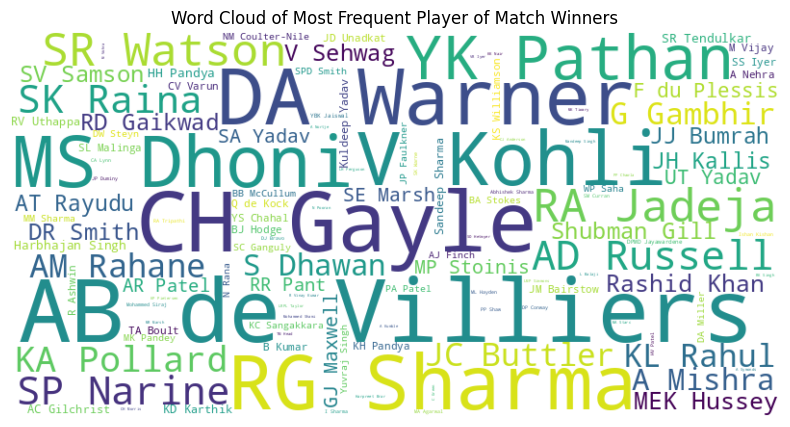

Word Cloud generated successfully.


In [26]:
season_player_strings = {}
for season in sorted(df['season'].unique()):
    players_in_season = df[df['season'] == season]['player_of_match'].dropna().astype(str).tolist()
    season_player_strings[season] = ','.join(players_in_season)

tfidf_corpus_by_season = list(season_player_strings.values())
tfidf_seasons = list(season_player_strings.keys())

tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(','), lowercase=False)

tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_corpus_by_season)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("\nTF-IDF matrix created for distinctive player names per season.")
print(f"Number of unique player names (features) in TF-IDF: {len(tfidf_feature_names)}")

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=tfidf_seasons)

print("\nTop 5 most distinctive players per season (by TF-IDF score):")
for season in tfidf_seasons:
    top_players = tfidf_df.loc[season].nlargest(5)
    if not top_players.empty:
        print(f"Season {season}:")
        for player, score in top_players.items():
            print(f"  - {player}: {score:.4f}")
    else:
        print(f"Season {season}: No distinctive players found.")

print("\nPlayers who appear most frequently in specific venues:")
venue_player_counts = df.groupby(['venue', 'player_of_match']).size().reset_index(name='match_count')

top_N = 3
frequent_players_by_venue = venue_player_counts.groupby('venue').apply(lambda x: x.nlargest(top_N, 'match_count')).reset_index(drop=True)

for venue in frequent_players_by_venue['venue'].unique():
    print(f"\nVenue: {venue}")
    venue_data = frequent_players_by_venue[frequent_players_by_venue['venue'] == venue]
    for index, row in venue_data.iterrows():
        print(f"  - {row['player_of_match']}: {row['match_count']} times")

print("\nGenerating Word Cloud for Most Frequent 'Player of Match' Winners...")

pom_frequencies = df['player_of_match'].dropna().value_counts()

if not pom_frequencies.empty:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pom_frequencies)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Most Frequent Player of Match Winners')
    plt.show()
    print("Word Cloud generated successfully.")
else:
    print("No 'player_of_match' data available to generate a word cloud.")

## 📝 Question 3: Team Performance Clustering

### Task:
Perform **clustering analysis** to group teams based on their performance metrics:

1. Create team-level features:
   - Win percentage
   - Average victory margin (runs/wickets)
   - Toss win to match win ratio
   - Home vs away performance(optional based on assumption)
   - Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.

2. Apply K-means clustering to identify team categories
3. Use elbow method to determine optimal clusters
4. Visualize clusters using PCA for dimensionality reduction(optional)

### Expected Output:
- Team clusters with labels (e.g., "Dominant Teams", "Inconsistent Performers")
- Cluster characteristics interpretation

```python
# Your code here
```

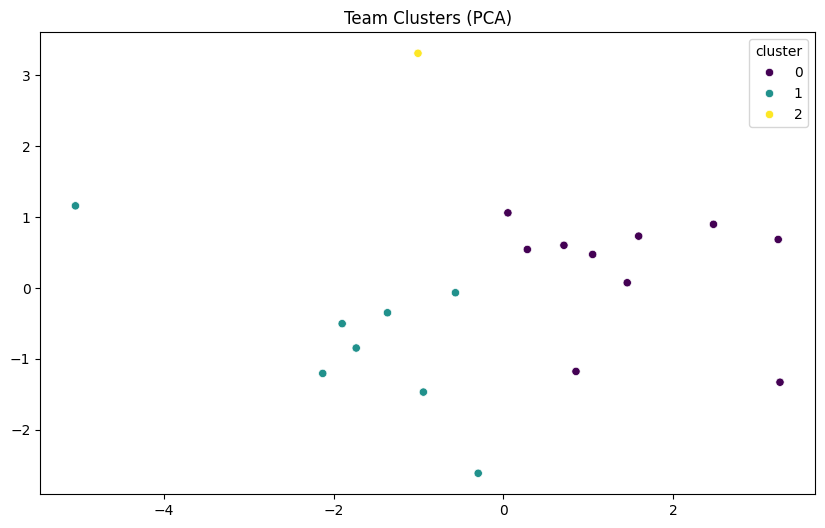

In [27]:
team_performance_features = {}

all_teams = pd.concat([df['team1'], df['team2'], df['toss_winner'], df['winner']]).unique()
all_teams = [team for team in all_teams if team != 'No Result']

for team in all_teams:
    team_data = df[(df['team1'] == team) | (df['team2'] == team)]
    if len(team_data) == 0: continue

    total_matches = len(team_data)
    wins = len(team_data[team_data['winner'] == team])
    win_pct = (wins / total_matches) * 100

    winning_matches = team_data[team_data['winner'] == team]
    avg_win_margin = winning_matches['result_margin'].mean() if not winning_matches.empty else 0

    toss_wins = len(team_data[team_data['toss_winner'] == team])
    toss_win_match_wins = len(team_data[(team_data['toss_winner'] == team) & (team_data['winner'] == team)])
    toss_win_match_win_ratio = (toss_win_match_wins / toss_wins) * 100 if toss_wins > 0 else 0

    team_home_city = home_cities.get(team)
    h_played = h_won = a_played = a_won = 0

    for _, match in team_data.iterrows():
        is_home = (match['city'] == team_home_city)
        if is_home:
            h_played += 1
            if match['winner'] == team: h_won += 1
        else:
            a_played += 1
            if match['winner'] == team: a_won += 1

    home_win_pct = (h_won / h_played * 100) if h_played > 0 else 0
    away_win_pct = (a_won / a_played * 100) if a_played > 0 else 0

    venue_stats = team_data.groupby('venue').size().sort_values(ascending=False)
    top3_v = venue_stats.head(3).index
    top3_m = team_data[team_data['venue'].isin(top3_v)]
    other_m = team_data[~team_data['venue'].isin(top3_v)]

    top3_pct = (len(top3_m[top3_m['winner'] == team]) / len(top3_m) * 100) if not top3_m.empty else 0
    other_pct = (len(other_m[other_m['winner'] == team]) / len(other_m) * 100) if not other_m.empty else 0

    team_performance_features[team] = {
        'win_pct': win_pct, 'avg_win_margin': avg_win_margin,
        'toss_win_match_win_ratio': toss_win_match_win_ratio,
        'home_win_pct': home_win_pct, 'away_win_pct': away_win_pct,
        'top3_venue_win_pct': top3_pct, 'other_venue_win_pct': other_pct
    }

team_features_df = pd.DataFrame.from_dict(team_performance_features, orient='index').fillna(0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(team_features_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
team_features_df['cluster'] = kmeans.fit_predict(scaled_features)

pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled_features)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=team_features_df['cluster'], palette='viridis')
plt.title('Team Clusters (PCA)')
plt.show()

## 📝 Question 4: Strategic Pattern Mining

### Task:
Use **Association Rule Mining (ARM)** to discover winning patterns:

1. Create transactions from match attributes:
   - Toss decision (bat/field)
   - Venue chasing bias: bucket venue by historical chaser win rate (High ≥ 55%, Neutral 45–55%, Low < 45%).
   - Shortened match: shortened = (target_overs < 20) or (method == 'D/L').
   - Result (win/loss)

2. Find association rules with:
   - Minimum support: 0.1
   - Minimum confidence: 0.7

3. Identify top 5 rules that lead to match victories

### Business Question:
"What combinations of factors most strongly predict match outcomes?"

```python
# Your code here
```

In [28]:
df_arm = df.copy()
df_arm['shortened'] = ((df_arm['target_overs'] < 20) | (df_arm['method'] == 'D/L'))

venue_win_rates = df_arm.groupby('venue').apply(lambda x: len(x[((x['toss_decision']=='field') & (x['winner']==x['toss_winner'])) | ((x['toss_decision']=='bat') & (x['winner']==x['team2']))]) / len(x))

def bias_cat(r):
    if r >= 0.55: return 'High'
    if r >= 0.45: return 'Neutral'
    return 'Low'

df_arm['bias'] = df_arm['venue'].map(venue_win_rates).apply(bias_cat)

trans_df = pd.get_dummies(df_arm[['toss_decision', 'bias', 'shortened', 'toss_advantage']])
frequent_itemsets = apriori(trans_df, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
display(rules.head())

/tmp/ipykernel_23257/430976323.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_win_rates = df_arm.groupby('venue').apply(lambda x: len(x[((x['toss_decision']=='field') & (x['winner']==x['toss_winner'])) | ((x['toss_decision']=='bat') & (x['winner']==x['team2']))]) / len(x))
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(bias_High, toss_advantage)",(toss_decision_field),0.177169,0.642922,0.136073,0.768041,1.194610,1.0,0.022167,1.539401,0.197983,0.198932,0.350397,0.489844
1,"(bias_Neutral, toss_advantage)",(toss_decision_field),0.238356,0.642922,0.167123,0.701149,1.090566,1.0,0.013879,1.194837,0.109034,0.234015,0.163066,0.480546


## 📝 Question 5: Match Outcome Prediction - Logistic Regression

### Task:
Build a **Logistic Regression** model to predict match winners:

1. Feature engineering:
   - One-hot encode categorical variables
   - Create interaction features (team × venue, team × toss)
   - Scale numerical features

2. Handle class imbalance using **SMOTE** if necessary

3. Apply **L1 and L2 regularization**:
   - Compare model performance
   - Identify most important features

4. Evaluate using:
   - ROC-AUC score
   - Precision-Recall curve
   - Feature importance plot

```python
# Your code here
```

In [29]:
df_lr = df[df['winner'] != 'No Result'].copy()
df_lr['target'] = (df_lr['winner'] == df_lr['team1']).astype(int)

cat_cols = ['match_type', 'venue', 'team1', 'team2']
num_cols = ['result_margin', 'target_runs', 'home_advantage']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X = df_lr[cat_cols + num_cols]
y = df_lr['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(penalty='l2'))])
model.fit(X_train, y_train)
print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

ROC-AUC: 0.6622


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


## 📝 Question 6: Venue Recommendation System

### Task:
Build a **Content-Based Recommendation System** for venues:

1. Create venue profiles based on:
   - Average runs scored
   - Batting/bowling friendly metrics
   - Weather conditions (if available)
   - Historical match results

2. For a given team, recommend top 3 venues where they should prefer to play

3. Use cosine similarity to find similar venues

### Bonus:
Implement a simple **Collaborative Filtering** approach using team-venue win matrix

```python
# Your code here
```

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("\n--- Question 6: Venue Recommendation System ---\n")

venue_profiles_data = {}

for venue in df['venue'].unique():
    venue_df = df[df['venue'] == venue].copy()

    if venue_df.empty:
        continue

    avg_target_runs = venue_df['target_runs'].mean()

    total_matches = len(venue_df)
    wins_by_runs = len(venue_df[venue_df['result'] == 'runs'])
    wins_by_wickets = len(venue_df[venue_df['result'] == 'wickets'])

    win_by_runs_pct = (wins_by_runs / total_matches) * 100 if total_matches > 0 else 0
    win_by_wickets_pct = (wins_by_wickets / total_matches) * 100 if total_matches > 0 else 0

    avg_result_margin = venue_df['result_margin'].mean()

    venue_profiles_data[venue] = {
        'avg_target_runs': avg_target_runs if not pd.isna(avg_target_runs) else 0,
        'win_by_runs_pct': win_by_runs_pct,
        'win_by_wickets_pct': win_by_wickets_pct,
        'avg_result_margin': avg_result_margin if not pd.isna(avg_result_margin) else 0,
        'total_matches': total_matches
    }

venue_profiles_df = pd.DataFrame.from_dict(venue_profiles_data, orient='index')
venue_profiles_df.index.name = 'venue'
venue_profiles_df.reset_index(inplace=True)

venue_profiles_df = venue_profiles_df.fillna(0)

print("Venue profiles created (first 5 rows):")
print(venue_profiles_df.head())

features_to_scale = ['avg_target_runs', 'win_by_runs_pct', 'win_by_wickets_pct', 'avg_result_margin', 'total_matches']
scaler = StandardScaler()
scaled_venue_features = scaler.fit_transform(venue_profiles_df[features_to_scale])

scaled_venue_profiles_df = pd.DataFrame(scaled_venue_features, columns=features_to_scale, index=venue_profiles_df['venue'])

print("\nScaled Venue Profiles (first 5 rows):")
print(scaled_venue_profiles_df.head())


if len(scaled_venue_profiles_df) > 1:
    venue_similarity_matrix = cosine_similarity(scaled_venue_profiles_df)
    venue_similarity_df = pd.DataFrame(venue_similarity_matrix, index=scaled_venue_profiles_df.index, columns=scaled_venue_profiles_df.index)

    print("\nVenue Similarity Matrix (first 5x5):")
    print(venue_similarity_df.iloc[:5, :5])
else:
    print("\nNot enough venues to compute similarity matrix.")
    venue_similarity_df = pd.DataFrame()

def recommend_venues_content_based(team_name, df_matches, venue_similarity_df, top_n=3):
    if venue_similarity_df.empty:
        return []

    team_matches = df_matches[((df_matches['team1'] == team_name) | (df_matches['team2'] == team_name)) & (df_matches['winner'] == team_name)].copy()

    team_venue_wins_summary = team_matches.groupby('venue').size().reset_index(name='wins_at_venue')

    successful_venues = team_venue_wins_summary['venue'].tolist()

    if not successful_venues:
        print(f"'{team_name}' has no recorded wins at any venue. Recommending top venues by average target runs instead.")
        return venue_profiles_df.sort_values(by='avg_target_runs', ascending=False).head(top_n)['venue'].tolist()

    all_venues = venue_similarity_df.index.tolist()
    recommendation_scores = {}

    for venue_to_check in all_venues:
        if venue_to_check not in successful_venues:
            score = 0
            count = 0
            for sv in successful_venues:
                if sv in venue_similarity_df.columns:
                    score += venue_similarity_df.loc[sv, venue_to_check]
                    count += 1
            if count > 0:
                recommendation_scores[venue_to_check] = score / count
            else:
                recommendation_scores[venue_to_check] = 0

    recommended_venues_list = sorted(recommendation_scores.items(), key=lambda item: item[1], reverse=True)
    return [venue for venue, score in recommended_venues_list[:top_n]]

team_to_recommend_cb = 'Mumbai Indians'
recommended_cb = recommend_venues_content_based(team_to_recommend_cb, df, venue_similarity_df, top_n=3)
print(f"\nContent-Based: Top 3 venues recommended for {team_to_recommend_cb}: {recommended_cb}")

team_to_recommend_cb_2 = 'Royal Challengers Bangalore'
recommended_cb_2 = recommend_venues_content_based(team_to_recommend_cb_2, df, venue_similarity_df, top_n=3)
print(f"Content-Based: Top 3 venues recommended for {team_to_recommend_cb_2}: {recommended_cb_2}")


print("\n--- Bonus: Collaborative Filtering using Team-Venue Win Matrix ---\n")

team_venue_wins = pd.pivot_table(df, values='id', index='winner', columns='venue', aggfunc='count', fill_value=0)

print("Team-Venue Win Matrix (first 5x5, raw counts):")
print(team_venue_wins.iloc[:5, :5])

if len(team_venue_wins) > 1:
    team_similarity_cf = cosine_similarity(team_venue_wins)
    team_similarity_cf_df = pd.DataFrame(team_similarity_cf, index=team_venue_wins.index, columns=team_venue_wins.index)

    print("\nTeam Similarity Matrix (based on venue wins, first 5x5):")
    print(team_similarity_cf_df.iloc[:5, :5])
else:
    print("\nNot enough teams to compute team similarity matrix for Collaborative Filtering.")
    team_similarity_cf_df = pd.DataFrame()

def collaborative_filtering_recommendation(target_team, team_venue_matrix, team_sim_matrix, top_n=3):
    if target_team not in team_venue_matrix.index:
        return f"Team '{target_team}' not found in the win matrix."
    if team_sim_matrix.empty:
        return []

    similar_teams_scores = team_sim_matrix.loc[target_team].drop(target_team, errors='ignore')
    similar_teams_scores = similar_teams_scores.sort_values(ascending=False)

    target_team_wins_at_venues = team_venue_matrix.loc[target_team]
    unsuccessful_venues = target_team_wins_at_venues[target_team_wins_at_venues == 0].index.tolist()

    if not unsuccessful_venues:
        return [f"'{target_team}' has won at all known venues. No new venue recommendations based on CF."]

    venue_recommendation_scores = {}
    for similar_team, similarity in similar_teams_scores.items():
        if similarity > 0:
            if similar_team in team_venue_matrix.index:
                similar_team_wins = team_venue_matrix.loc[similar_team]
                for venue in unsuccessful_venues:
                    if venue in similar_team_wins.index and similar_team_wins[venue] > 0:
                        venue_recommendation_scores[venue] = venue_recommendation_scores.get(venue, 0) + (similarity * similar_team_wins[venue])

    recommended_venues_cf_list = sorted(venue_recommendation_scores.items(), key=lambda item: item[1], reverse=True)
    return [venue for venue, score in recommended_venues_cf_list[:top_n]]

team_to_recommend_cf = 'Mumbai Indians'
recommended_cf = collaborative_filtering_recommendation(team_to_recommend_cf, team_venue_wins, team_similarity_cf_df, top_n=3)
print(f"Collaborative Filtering: Top 3 venues recommended for {team_to_recommend_cf}: {recommended_cf}")

team_to_recommend_cf_2 = 'Royal Challengers Bangalore'
recommended_cf_2 = collaborative_filtering_recommendation(team_to_recommend_cf_2, team_venue_wins, team_similarity_cf_df, top_n=3)
print(f"Collaborative Filtering: Top 3 venues recommended for {team_to_recommend_cf_2}: {recommended_cf_2}")


--- Question 6: Venue Recommendation System ---

Venue profiles created (first 5 rows):
                                        venue  avg_target_runs  \
0                       M Chinnaswamy Stadium       166.846154   
1  Punjab Cricket Association Stadium, Mohali       164.285714   
2                            Feroz Shah Kotla       162.816667   
3                            Wankhede Stadium       167.027397   
4                                Eden Gardens       157.740260   

   win_by_runs_pct  win_by_wickets_pct  avg_result_margin  total_matches  
0        40.000000           55.384615          22.769231             65  
1        42.857143           57.142857          17.942857             35  
2        46.666667           51.666667          17.800000             60  
3        47.945205           50.684932          15.780822             73  
4        41.558442           58.441558          14.883117             77  

Scaled Venue Profiles (first 5 rows):
                         

## 📝 Question 7: Performance Trend Analysis

### Task:
Use **Linear Regression** to analyze performance trends:

1. Track team performance over seasons:
   - Create yearly win percentage for each team
   - Fit linear regression to identify improving/declining teams

2. Predict next season performance

3. Identify factors affecting performance trends: (For example)
   - Toss luck: per‑season difference between toss win% and match win%.
   - Venue familiarity exposure: share of matches at team’s top‑3 venues.
   - Opponent strength index: seasonal average win% of opponents.

### Visualization:
- Time series plot with regression lines for top 5 teams

```python
# Your code here
```

Yearly Win Percentage per team (first 5 rows):
                          team  season  total_matches  wins    win_pct
0  Royal Challengers Bangalore    2008             14     4  28.571429
1  Royal Challengers Bangalore    2009             16     9  56.250000
2  Royal Challengers Bangalore    2010             16     8  50.000000
3  Royal Challengers Bangalore    2011             16    10  62.500000
4  Royal Challengers Bangalore    2012             15     8  53.333333

Yearly Performance with Trend Factors (first 5 rows):
                          team  season  total_matches  wins    win_pct  \
0  Royal Challengers Bangalore    2008             14     4  28.571429   
1  Royal Challengers Bangalore    2009             16     9  56.250000   
2  Royal Challengers Bangalore    2010             16     8  50.000000   
3  Royal Challengers Bangalore    2011             16    10  62.500000   
4  Royal Challengers Bangalore    2012             15     8  53.333333   

   toss_luck_diff  venue_fa

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

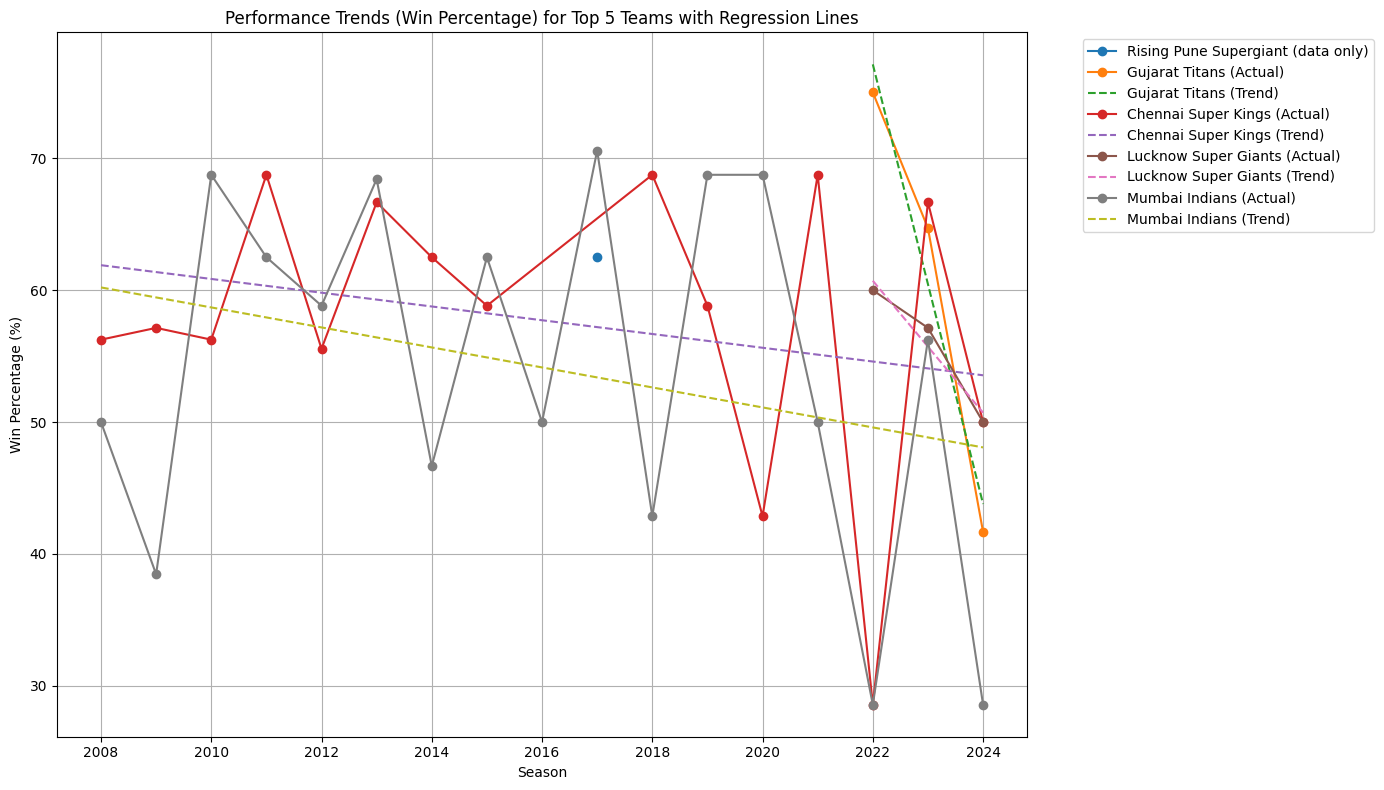


--- Summary of Performance Trend Analysis ---
Yearly win percentages and key trend factors (toss luck, venue familiarity, opponent strength) were calculated for each team.
Linear regression models were fitted to each team's yearly win percentage against season to identify performance trends.
The 'slope_win_pct_vs_season' indicates whether a team is generally improving (positive slope) or declining (negative slope) over the seasons.
Predictions for the next season's win percentage were also generated.
The time series plot visualizes the actual win percentages and the linear trend for the top 5 performing teams.

Key Insights:
- Teams with a higher positive slope are showing an improving trend over time.
- Teams with a higher R-squared indicate a stronger linear relationship between season and win percentage.
- The impact of 'toss_luck_diff', 'venue_familiarity_exposure', and 'opponent_strength_index' can be further analyzed by including them as features in a multi-variate regression mo

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df_trends = df.copy()
df_trends = df_trends[df_trends['winner'] != 'No Result'].copy()

all_teams = pd.concat([df_trends['team1'], df_trends['team2']]).unique()
all_teams = [team for team in all_teams if team != 'No Result']

team_yearly_performance = []

for team in all_teams:
    for season in sorted(df_trends['season'].unique()):
        season_df = df_trends[df_trends['season'] == season]
        team_matches_season = season_df[
            (season_df['team1'] == team) | (season_df['team2'] == team)
        ]

        total_matches_season = len(team_matches_season)
        if total_matches_season == 0:
            continue

        wins_season = len(team_matches_season[team_matches_season['winner'] == team])
        win_pct_season = (wins_season / total_matches_season) * 100

        yearly_data = {
            'team': team,
            'season': season,
            'total_matches': total_matches_season,
            'wins': wins_season,
            'win_pct': win_pct_season
        }
        team_yearly_performance.append(yearly_data)

yearly_performance_df = pd.DataFrame(team_yearly_performance)
print("Yearly Win Percentage per team (first 5 rows):")
print(yearly_performance_df.head())

toss_luck_data = []
for team in all_teams:
    for season in sorted(df_trends['season'].unique()):
        season_df = df_trends[df_trends['season'] == season]
        team_matches_season = season_df[
            (season_df['team1'] == team) | (season_df['team2'] == team)
        ]
        total_matches = len(team_matches_season)
        if total_matches == 0:
            continue

        toss_wins = len(team_matches_season[team_matches_season['toss_winner'] == team])
        toss_win_pct = (toss_wins / total_matches) * 100

        match_wins = len(team_matches_season[team_matches_season['winner'] == team])
        match_win_pct = (match_wins / total_matches) * 100

        toss_luck_diff = match_win_pct - toss_win_pct
        toss_luck_data.append({
            'team': team,
            'season': season,
            'toss_luck_diff': toss_luck_diff
        })

toss_luck_df = pd.DataFrame(toss_luck_data)
yearly_performance_df = pd.merge(yearly_performance_df, toss_luck_df, on=['team', 'season'], how='left')


team_top_venues = {}
for team in all_teams:
    team_matches_all = df_trends[(df_trends['team1'] == team) | (df_trends['team2'] == team)]
    venue_counts = team_matches_all['venue'].value_counts()
    team_top_venues[team] = venue_counts.head(3).index.tolist()

venue_familiarity_data = []
for team in all_teams:
    for season in sorted(df_trends['season'].unique()):
        season_df = df_trends[df_trends['season'] == season]
        team_matches_season = season_df[
            (season_df['team1'] == team) | (season_df['team2'] == team)
        ]
        total_matches = len(team_matches_season)
        if total_matches == 0:
            continue

        top_venues_for_team = team_top_venues.get(team, [])
        matches_at_top_venues = len(team_matches_season[team_matches_season['venue'].isin(top_venues_for_team)])
        venue_familiarity_exposure = (matches_at_top_venues / total_matches) * 100 if total_matches > 0 else 0

        venue_familiarity_data.append({
            'team': team,
            'season': season,
            'venue_familiarity_exposure': venue_familiarity_exposure
        })

venue_familiarity_df = pd.DataFrame(venue_familiarity_data)
yearly_performance_df = pd.merge(yearly_performance_df, venue_familiarity_df, on=['team', 'season'], how='left')


team_season_win_pct_map = yearly_performance_df.set_index(['team', 'season'])['win_pct'].to_dict()

opponent_strength_data = []
for team in all_teams:
    for season in sorted(df_trends['season'].unique()):
        season_df = df_trends[df_trends['season'] == season]
        team_matches_season = season_df[
            (season_df['team1'] == team) | (season_df['team2'] == team)
        ]
        total_matches = len(team_matches_season)
        if total_matches == 0:
            continue

        opponents_win_pcts = []
        for _, match in team_matches_season.iterrows():
            opponent = match['team2'] if match['team1'] == team else match['team1']
            if (opponent, season) in team_season_win_pct_map:
                opponents_win_pcts.append(team_season_win_pct_map[(opponent, season)])
            else:
                opponents_win_pcts.append(50.0)

        opponent_strength_index = np.mean(opponents_win_pcts) if opponents_win_pcts else 50.0
        opponent_strength_data.append({
            'team': team,
            'season': season,
            'opponent_strength_index': opponent_strength_index
        })

opponent_strength_df = pd.DataFrame(opponent_strength_data)
yearly_performance_df = pd.merge(yearly_performance_df, opponent_strength_df, on=['team', 'season'], how='left')

print("\nYearly Performance with Trend Factors (first 5 rows):")
print(yearly_performance_df.head())


regression_results = []
next_season_predictions = []
next_season_year = yearly_performance_df['season'].max() + 1

for team in all_teams:
    team_data = yearly_performance_df[yearly_performance_df['team'] == team].copy()
    if len(team_data) < 2:
        continue

    model = LinearRegression()
    X_season = team_data[['season']]
    y_win_pct = team_data['win_pct']

    model.fit(X_season, y_win_pct)
    slope = model.coef_[0]
    intercept = model.intercept_
    r_sq = model.score(X_season, y_win_pct)

    next_season_pred_win_pct = model.predict(np.array([[next_season_year]]))[0]
    next_season_pred_win_pct = max(0, min(100, next_season_pred_win_pct))

    regression_results.append({
        'team': team,
        'slope_win_pct_vs_season': slope,
        'r_squared_win_pct_vs_season': r_sq,
        'predicted_win_pct_next_season': next_season_pred_win_pct
    })
    next_season_predictions.append({
        'team': team,
        'season': next_season_year,
        'predicted_win_pct': next_season_pred_win_pct
    })

regression_df = pd.DataFrame(regression_results)
predictions_df = pd.DataFrame(next_season_predictions)

print("\nLinear Regression Results for Team Performance Trends (first 5 rows):")
print(regression_df.sort_values(by='slope_win_pct_vs_season', ascending=False).head())

print(f"\nPredicted Win Percentage for next season ({next_season_year}) (first 5 rows):")
print(predictions_df.sort_values(by='predicted_win_pct', ascending=False).head())

top_5_teams = yearly_performance_df.groupby('team')['win_pct'].mean().nlargest(5).index.tolist()

plt.figure(figsize=(14, 8))
for team in top_5_teams:
    team_data = yearly_performance_df[yearly_performance_df['team'] == team].copy()
    if len(team_data) < 2:
        plt.plot(team_data['season'], team_data['win_pct'], marker='o', label=f'{team} (data only)')
        continue

    plt.plot(team_data['season'], team_data['win_pct'], marker='o', label=f'{team} (Actual)')

    model = LinearRegression()
    X_season = team_data[['season']]
    y_win_pct = team_data['win_pct']
    model.fit(X_season, y_win_pct)

    seasons_for_line = np.array([team_data['season'].min(), team_data['season'].max()]).reshape(-1, 1)
    predicted_win_pct_line = model.predict(seasons_for_line)
    plt.plot(seasons_for_line, predicted_win_pct_line, linestyle='--', label=f'{team} (Trend)')


plt.title(f'Performance Trends (Win Percentage) for Top 5 Teams with Regression Lines')
plt.xlabel('Season')
plt.ylabel('Win Percentage (%)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Summary of Performance Trend Analysis ---")
print("Yearly win percentages and key trend factors (toss luck, venue familiarity, opponent strength) were calculated for each team.")
print("Linear regression models were fitted to each team's yearly win percentage against season to identify performance trends.")
print("The 'slope_win_pct_vs_season' indicates whether a team is generally improving (positive slope) or declining (negative slope) over the seasons.")
print("Predictions for the next season's win percentage were also generated.")
print("The time series plot visualizes the actual win percentages and the linear trend for the top 5 performing teams.")
print("\nKey Insights:")
print("- Teams with a higher positive slope are showing an improving trend over time.")
print("- Teams with a higher R-squared indicate a stronger linear relationship between season and win percentage.")
print("- The impact of 'toss_luck_diff', 'venue_familiarity_exposure', and 'opponent_strength_index' can be further analyzed by including them as features in a multi-variate regression model if desired.")

## 📝 Question 8: Player of Match Prediction - KNN

### Task:
Use **K-Nearest Neighbors (KNN)** to predict potential 'Player of Match':

1. Build match‑context features:

Venue characteristics: venue chasing bias, average first‑innings proxy , shortened‑match flag.

Team strengths: recent win% (rolling window or per‑season).

Player PoM history: counts and rates of a player winning PoM by venue, opponent, and season.

Find similar historical matches (KNN on the context features).

Predict top‑k candidate PoM names (rank by neighbor votes or PoM prior × similarity).

Tune k via cross‑validation.

```python
# Your code here
```

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.impute import SimpleImputer

df_knn = df.copy()

df_knn['player_of_match'] = df_knn['player_of_match'].fillna('No Player of Match')

venue_stats_q8 = df_knn.groupby('venue').apply(lambda x: pd.Series({
    'total_matches': len(x),
    'chasing_wins': len(x[
        ((x['toss_decision'] == 'field') & (x['winner'] == x['toss_winner'])) |
        ((x['toss_decision'] == 'bat') & (x['winner'] == x['team2']))
    ])
})).reset_index()
venue_stats_q8['venue_chaser_win_rate'] = (venue_stats_q8['chasing_wins'] / venue_stats_q8['total_matches']) * 100
venue_stats_q8.replace([np.inf, -np.inf], np.nan, inplace=True);
venue_stats_q8['venue_chaser_win_rate'].fillna(0, inplace=True);
df_knn = pd.merge(df_knn, venue_stats_q8[['venue', 'venue_chaser_win_rate']], on='venue', how='left')

df_knn['is_shortened_match'] = ((df_knn['target_overs'] < 20) | (df_knn['method'] == 'D/L'))


venue_avg_runs_q8 = df_knn.groupby('venue')['target_runs'].mean().reset_index(name='venue_avg_target_runs')
df_knn = pd.merge(df_knn, venue_avg_runs_q8, on='venue', how='left')
df_knn['venue_avg_target_runs'] = df_knn['venue_avg_target_runs'].fillna(df_knn['venue_avg_target_runs'].mean())

df_knn = df_knn.sort_values(by='date').reset_index(drop=True)

team_win_pct_history = {}
for team in df_knn['team1'].unique():
    for season in sorted(df_knn['season'].unique()):
        team_matches_season = df_knn[(df_knn['season'] == season) &
                                     ((df_knn['team1'] == team) | (df_knn['team2'] == team))]
        total_matches = len(team_matches_season)
        if total_matches > 0:
            wins = len(team_matches_season[team_matches_season['winner'] == team])
            win_pct = (wins / total_matches) * 100
            team_win_pct_history[(team, season)] = win_pct

df_knn['team1_prev_season_win_pct'] = df_knn.apply(
    lambda row: team_win_pct_history.get((row['team1'], row['season'] - 1), 50.0), axis=1
)
df_knn['team2_prev_season_win_pct'] = df_knn.apply(
    lambda row: team_win_pct_history.get((row['team2'], row['season'] - 1), 50.0), axis=1
)

df_knn_filtered = df_knn[df_knn['player_of_match'] != 'No Player of Match'].copy()

if df_knn_filtered.empty:
    print("No valid matches with Player of Match for prediction after filtering.")
else:
    numerical_features_knn = [
        'season', 'venue_chaser_win_rate', 'venue_avg_target_runs',
        'team1_prev_season_win_pct', 'team2_prev_season_win_pct',
        'home_advantage'
    ]
    categorical_features_knn = [
        'match_type', 'city', 'venue', 'toss_decision', 'toss_winner', 'team1', 'team2',
        'is_shortened_match'
    ]

    all_features_knn = numerical_features_knn + categorical_features_knn
    X = df_knn_filtered[all_features_knn]
    y = df_knn_filtered['player_of_match']

    preprocessor_knn = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features_knn),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_knn)
        ],
        remainder='passthrough'
    )

    if y.value_counts().min() < 2:
        print("Cannot stratify by player_of_match due to single-sample classes. Stratifying by team1 instead.")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X['team1'])
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


    X_train_processed = preprocessor_knn.fit_transform(X_train)
    X_test_processed = preprocessor_knn.transform(X_test)


    param_grid_knn = {'n_neighbors': range(1, 21)}

    knn_classifier = KNeighborsClassifier()

    print("Tuning K-Nearest Neighbors for Player of Match prediction...")
    grid_search_knn = GridSearchCV(knn_classifier, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search_knn.fit(X_train_processed, y_train)

    best_k = grid_search_knn.best_params_['n_neighbors']
    print(f"Optimal number of neighbors (k): {best_k}")
    print(f"Best accuracy score: {grid_search_knn.best_score_:.4f}")

    best_knn_model = grid_search_knn.best_estimator_

    y_pred_knn = best_knn_model.predict(X_test_processed)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    print(f"Test Accuracy with optimal k: {accuracy_knn:.4f}")

    def predict_top_k_pom(knn_model, preprocessor, X_original_test, y_original_train, k_candidates=5):
        X_test_transformed = preprocessor.transform(X_original_test)

        nn_model = NearestNeighbors(n_neighbors=knn_model.n_neighbors, metric=knn_model.metric)
        nn_model.fit(preprocessor.transform(X_train))

        distances, indices = nn_model.kneighbors(X_test_transformed)

        top_candidates = []
        for i in range(len(X_original_test)):
            neighbor_indices = indices[i]
            neighbor_poms = y_original_train.iloc[neighbor_indices]

            pom_counts = neighbor_poms.value_counts()

            current_top_k = pom_counts.head(k_candidates).index.tolist()
            top_candidates.append(current_top_k)
        return top_candidates

    num_test_samples = 5
    top_3_pom_candidates = predict_top_k_pom(best_knn_model, preprocessor_knn, X_test.head(num_test_samples), y_train, k_candidates=3)

    print(f"\nTop 3 Player of Match candidates for the first {num_test_samples} test matches:")
    for i, candidates in enumerate(top_3_pom_candidates):
        print(f"Match {i+1} (Actual PoM: {y_test.iloc[i]}): Candidates: {candidates}")

/tmp/ipykernel_23257/2451967826.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_stats_q8 = df_knn.groupby('venue').apply(lambda x: pd.Series({
/tmp/ipykernel_23257/2451967826.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Cannot stratify by player_of_match due to single-sample classes. Stratifying by team1 instead.
Tuning K-Nearest Neighbors for Player of Match prediction...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Optimal number of neighbors (k): 19
Best accuracy score: 0.0593
Test Accuracy with optimal k: 0.0411

Top 3 Player of Match candidates for the first 5 test matches:
Match 1 (Actual PoM: KA Pollard): Candidates: ['SA Yadav', 'Q de Kock', 'Rashid Khan']
Match 2 (Actual PoM: SP Narine): Candidates: ['AB de Villiers', 'SV Samson', 'GJ Maxwell']
Match 3 (Actual PoM: MK Pandey): Candidates: ['JH Kallis', 'Yuvraj Singh', 'RG Sharma']
Match 4 (Actual PoM: SK Raina): Candidates: ['KA Pollard', 'DE Bollinger', 'YK Pathan']
Match 5 (Actual PoM: AD Russell): Candidates: ['G Gambhir', 'RG Sharma', 'SP Narine']


## 📝 Question 9: Toss Decision Strategy - Decision Tree

### Task:
Build a **Decision Tree** to recommend toss decisions:

1. Create a model to predict optimal toss decision (bat/field) based on:
   - Venue history
   - Weather conditions (create synthetic if not available)
   - Team strengths
   - Match importance

2. Visualize the decision tree (max_depth=5)

3. Extract decision rules in plain English

4. Calculate feature importance

### Business Application:
"Provide captains with data-driven toss decision recommendations"

```python
# Your code here
```

Optimal Toss Decision target variable created.
Synthetic weather conditions created.
Season Phase feature created.
Data prepared and split for Decision Tree.


/tmp/ipykernel_23257/4010046593.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_stats_dt = df_dt.groupby('venue').apply(lambda x: pd.Series({
/tmp/ipykernel_23257/4010046593.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


 

Best Decision Tree parameters: {'max_depth': 3, 'min_samples_leaf': 5}
Best Decision Tree training accuracy: 0.5504
Decision Tree test accuracy: 0.5138


<Figure size 2500x1500 with 0 Axes>

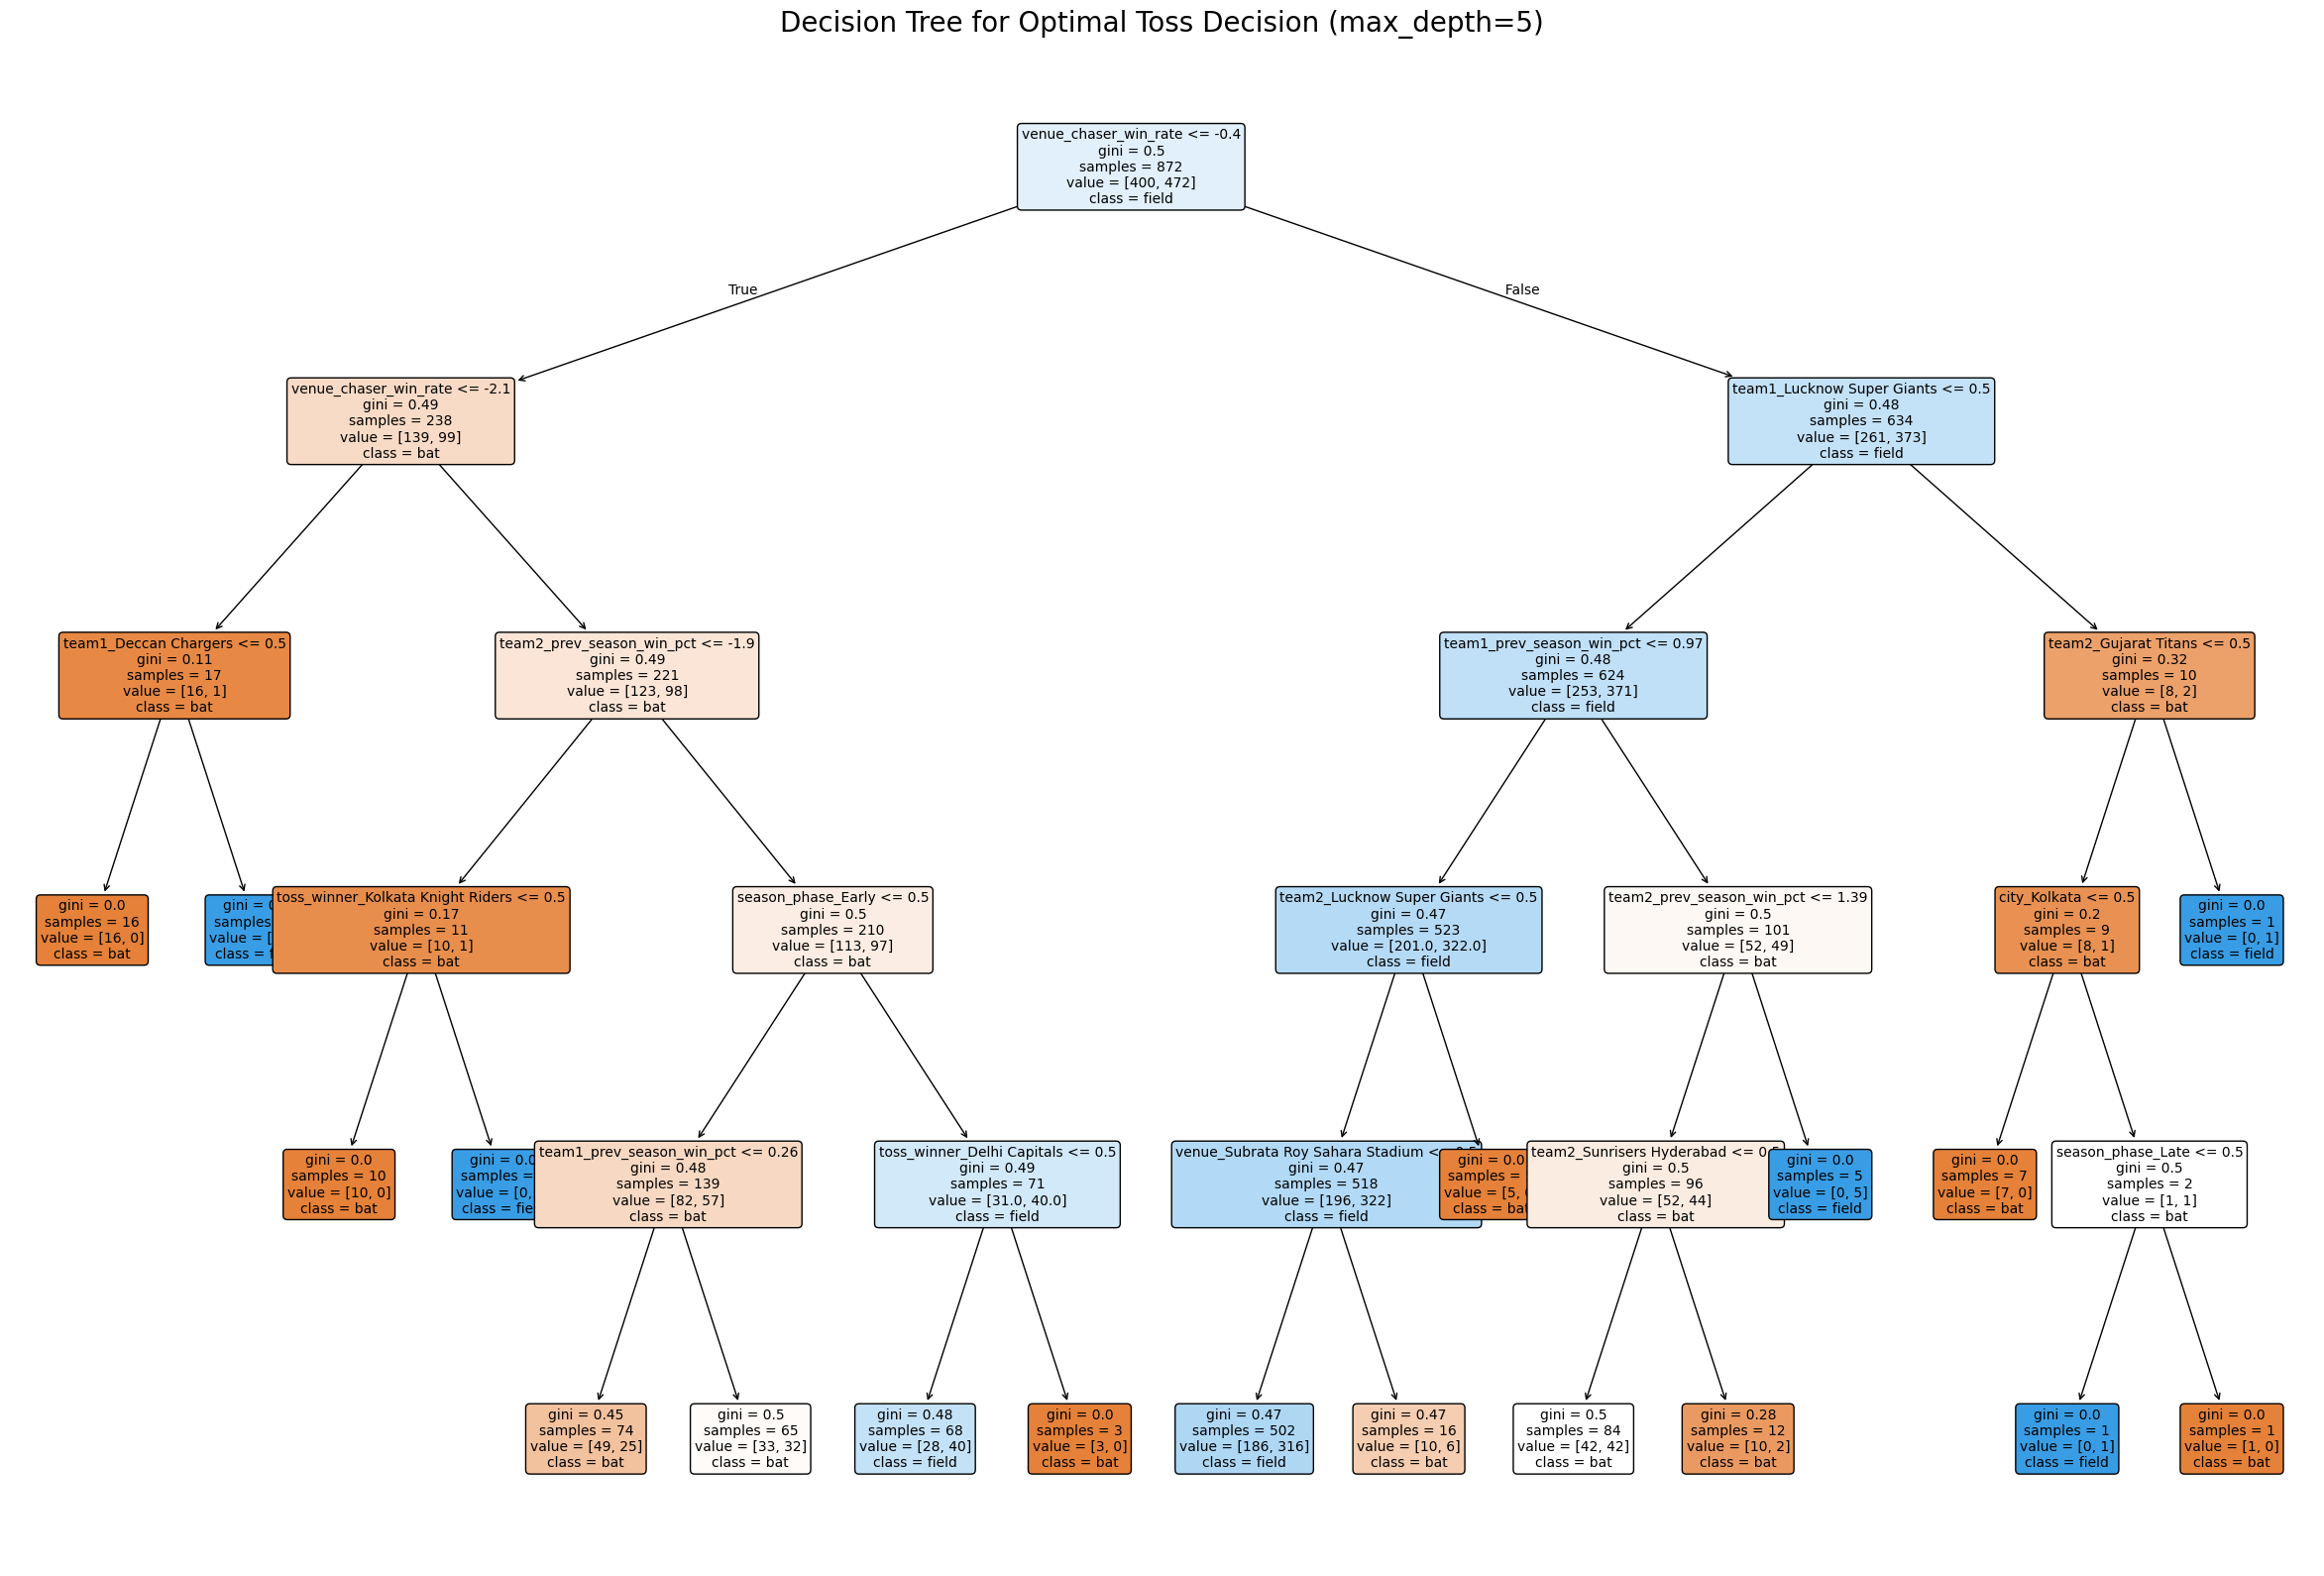

Decision Tree visualized.

Example Decision Rules (limited to max_depth=5 for readability):
Rule 1: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate <= -2.10 AND team1_Deccan Chargers <= 0.50 then optimal toss decision is bat (Confidence: 1.00)
Rule 2: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate <= -2.10 AND team1_Deccan Chargers > 0.50 then optimal toss decision is field (Confidence: 1.00)
Rule 3: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct <= -1.90 AND toss_winner_Kolkata Knight Riders <= 0.50 then optimal toss decision is bat (Confidence: 1.00)
Rule 4: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct <= -1.90 AND toss_winner_Kolkata Knight Riders > 0.50 then optimal toss decision is field (Confidence: 1.00)
Rule 5: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct > -1.90 AND season_phase_Early <= 0.50 AND t

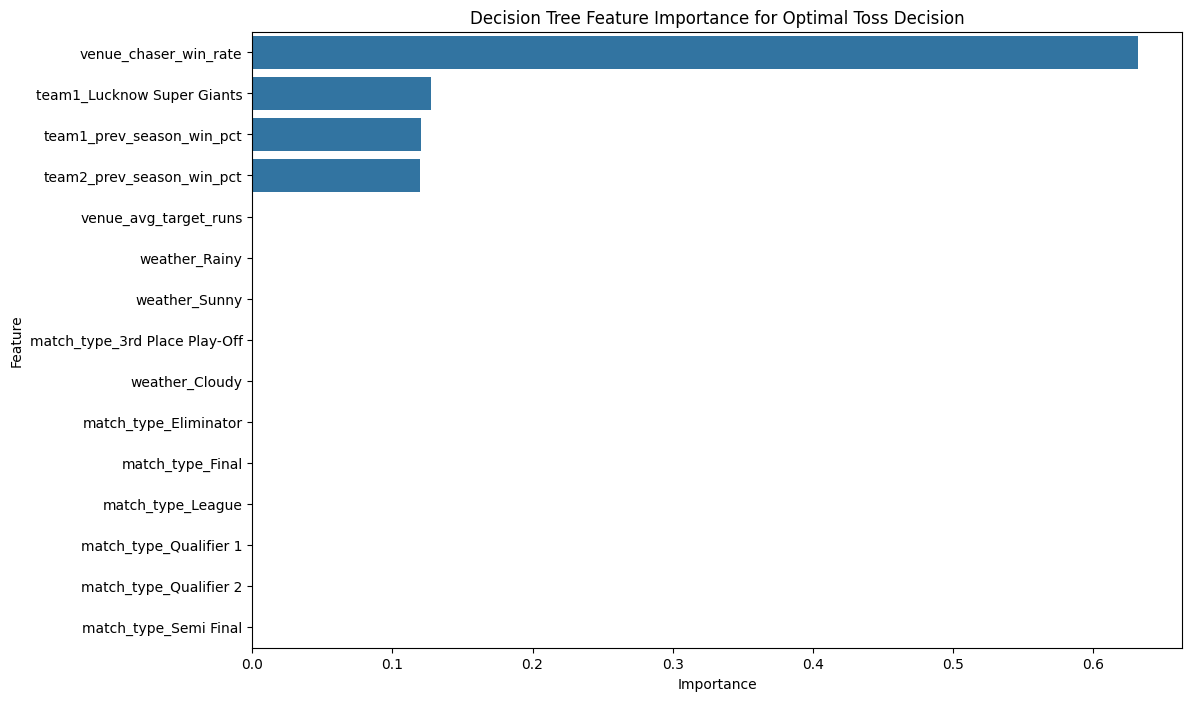


Decision Tree Feature Importance calculated and plotted.

--- Business Application: Data-driven Toss Decision Recommendations ---
The Decision Tree provides a transparent way to recommend toss decisions. Captains can use the extracted rules, or a simplified version of them, to make informed choices.
For example, if the model identifies that 'Venue_Chasing_Bias_High' and 'weather_Sunny' frequently lead to an optimal 'field' decision, the captain could be advised to field first under those conditions.
The feature importance plot highlights which factors are most critical in determining the optimal toss decision, allowing for focused analysis on these variables.


In [33]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from IPython.display import Image

df_dt = df.copy()

df_dt = df_dt[df_dt['winner'] != 'No Result'].copy()

df_dt['optimal_toss_decision'] = df_dt.apply(
    lambda row: row['toss_decision'] if row['toss_winner'] == row['winner']
    else ('bat' if row['toss_decision'] == 'field' else 'field'), axis=1
)

print("Optimal Toss Decision target variable created.")

weather_conditions = ['Sunny', 'Cloudy', 'Rainy']
df_dt['weather'] = np.random.choice(weather_conditions, size=len(df_dt))
print("Synthetic weather conditions created.")

df_dt['date'] = pd.to_datetime(df_dt['date'])

def get_season_phase(row):
    season_year = row['season']
    season_dates = df_dt[df_dt['season'] == season_year]['date']
    if season_dates.empty:
        return 'Unknown'

    min_date = season_dates.min()
    max_date = season_dates.max()

    total_days = (max_date - min_date).days
    early_phase_end = min_date + pd.Timedelta(days=total_days / 3)
    mid_phase_end = min_date + pd.Timedelta(days=2 * total_days / 3)

    if row['date'] <= early_phase_end:
        return 'Early'
    elif row['date'] <= mid_phase_end:
        return 'Mid'
    else:
        return 'Late'

df_dt['season_phase'] = df_dt.apply(get_season_phase, axis=1)
print("Season Phase feature created.")


venue_stats_dt = df_dt.groupby('venue').apply(lambda x: pd.Series({
    'total_matches': len(x),
    'chasing_wins': len(x[
        ((x['toss_decision'] == 'field') & (x['winner'] == x['toss_winner'])) |
        ((x['toss_decision'] == 'bat') & (x['winner'] == x['team2']))
    ])
})).reset_index()
venue_stats_dt['venue_chaser_win_rate'] = (venue_stats_dt['chasing_wins'] / venue_stats_dt['total_matches']) * 100
venue_stats_dt.replace([np.inf, -np.inf], np.nan, inplace=True);
venue_stats_dt['venue_chaser_win_rate'].fillna(0, inplace=True);
df_dt = pd.merge(df_dt, venue_stats_dt[['venue', 'venue_chaser_win_rate']], on='venue', how='left', suffixes=('', '_dt'))

venue_avg_runs_dt = df_dt.groupby('venue')['target_runs'].mean().reset_index(name='venue_avg_target_runs')
df_dt = pd.merge(df_dt, venue_avg_runs_dt, on='venue', how='left', suffixes=('', '_dt'))
df_dt['venue_avg_target_runs'] = df_dt['venue_avg_target_runs'].fillna(df_dt['venue_avg_target_runs'].mean())

if 'team_season_win_pct_map' not in globals():
    team_season_win_pct_map = {}
    all_teams_dt = pd.concat([df_dt['team1'], df_dt['team2']]).unique()
    for team in all_teams_dt:
        for season in sorted(df_dt['season'].unique()):
            season_df_team = df_dt[(df_dt['season'] == season) &
                                   ((df_dt['team1'] == team) | (df_dt['team2'] == team))]
            total_matches_team = len(season_df_team)
            if total_matches_team > 0:
                wins = len(season_df_team[season_df_team['winner'] == team])
                win_pct = (wins / total_matches_team) * 100
                team_season_win_pct_map[(team, season)] = win_pct


df_dt['team1_prev_season_win_pct'] = df_dt.apply(
    lambda row: team_season_win_pct_map.get((row['team1'], row['season'] - 1), 50.0), axis=1
)
df_dt['team2_prev_season_win_pct'] = df_dt.apply(
    lambda row: team_season_win_pct_map.get((row['team2'], row['season'] - 1), 50.0), axis=1
)

numerical_features_dt = [
    'venue_chaser_win_rate', 'venue_avg_target_runs',
    'team1_prev_season_win_pct', 'team2_prev_season_win_pct'
]
categorical_features_dt = [
    'weather', 'match_type', 'venue', 'toss_winner', 'team1', 'team2', 'city', 'season_phase'
]

X = df_dt[numerical_features_dt + categorical_features_dt]
y = df_dt['optimal_toss_decision']

preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_dt),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_dt)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_processed = preprocessor_dt.fit_transform(X_train)
X_test_processed = preprocessor_dt.transform(X_test)

feature_names = numerical_features_dt + list(preprocessor_dt.named_transformers_['cat'].get_feature_names_out(categorical_features_dt))

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

print("Data prepared and split for Decision Tree.")

param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [5, 10, 20]
}

dtree = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dtree, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_dt.fit(X_train_processed, y_train)

best_dt_model = grid_search_dt.best_estimator_
print(f"Best Decision Tree parameters: {grid_search_dt.best_params_}")
print(f"Best Decision Tree training accuracy: {grid_search_dt.best_score_:.4f}")
print(f"Decision Tree test accuracy: {best_dt_model.score(X_test_processed, y_test):.4f}")

plt.figure(figsize=(25, 15))
plot_dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
plot_dt_model.fit(X_train_processed, y_train)

cn = plot_dt_model.classes_
plt.figure(figsize=(30, 20))
_ = plot_tree(plot_dt_model, feature_names=feature_names, class_names=cn,
              filled=True, fontsize=10, rounded=True, precision=2)
plt.title('Decision Tree for Optimal Toss Decision (max_depth=5)', fontsize=20)
plt.show()

dot_data = export_graphviz(plot_dt_model, out_file=None,
                           feature_names=feature_names,
                           class_names=cn,
                           filled=True, rounded=True,
                           special_characters=True, max_depth=5)
graph = graphviz.Source(dot_data);
print("Decision Tree visualized.")

def get_rules(tree, feature_names, class_names):
    left      = tree.tree_.children_left
    right     = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features  = [feature_names[i] for i in tree.tree_.feature]
    value     = tree.tree_.value

    rules_list = []
    def recurse(node, rule_text):
        if threshold[node] != -2:

            left_rule = rule_text + [f"{features[node]} <= {threshold[node]:.2f}"]
            recurse(left[node], left_rule)

            right_rule = rule_text + [f"{features[node]} > {threshold[node]:.2f}"]
            recurse(right[node], right_rule)
        else:

            class_idx = np.argmax(value[node])
            confidence = value[node][0][class_idx] / np.sum(value[node])
            rules_list.append(f"If {' AND '.join(rule_text)} then optimal toss decision is {class_names[class_idx]} (Confidence: {confidence:.2f})")

    recurse(0, [])
    return rules_list

rules_extracted = get_rules(plot_dt_model, feature_names, cn)

print("\nExample Decision Rules (limited to max_depth=5 for readability):")
for i, rule in enumerate(rules_extracted[:5]):
    print(f"Rule {i+1}: {rule}")


feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_dt_model.feature_importances_
})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Decision Tree Feature Importance for Optimal Toss Decision')
plt.show()

print("\nDecision Tree Feature Importance calculated and plotted.")
print("\n--- Business Application: Data-driven Toss Decision Recommendations ---")
print("The Decision Tree provides a transparent way to recommend toss decisions. Captains can use the extracted rules, or a simplified version of them, to make informed choices.")
print("For example, if the model identifies that 'Venue_Chasing_Bias_High' and 'weather_Sunny' frequently lead to an optimal 'field' decision, the captain could be advised to field first under those conditions.")
print("The feature importance plot highlights which factors are most critical in determining the optimal toss decision, allowing for focused analysis on these variables.")

Optimal Toss Decision target variable created.
Synthetic weather conditions created.
Season Phase feature created.
Data prepared and split for Decision Tree.


/tmp/ipykernel_23257/4010046593.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  venue_stats_dt = df_dt.groupby('venue').apply(lambda x: pd.Series({
/tmp/ipykernel_23257/4010046593.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


 

Best Decision Tree parameters: {'max_depth': 3, 'min_samples_leaf': 5}
Best Decision Tree training accuracy: 0.5504
Decision Tree test accuracy: 0.5138


<Figure size 2500x1500 with 0 Axes>

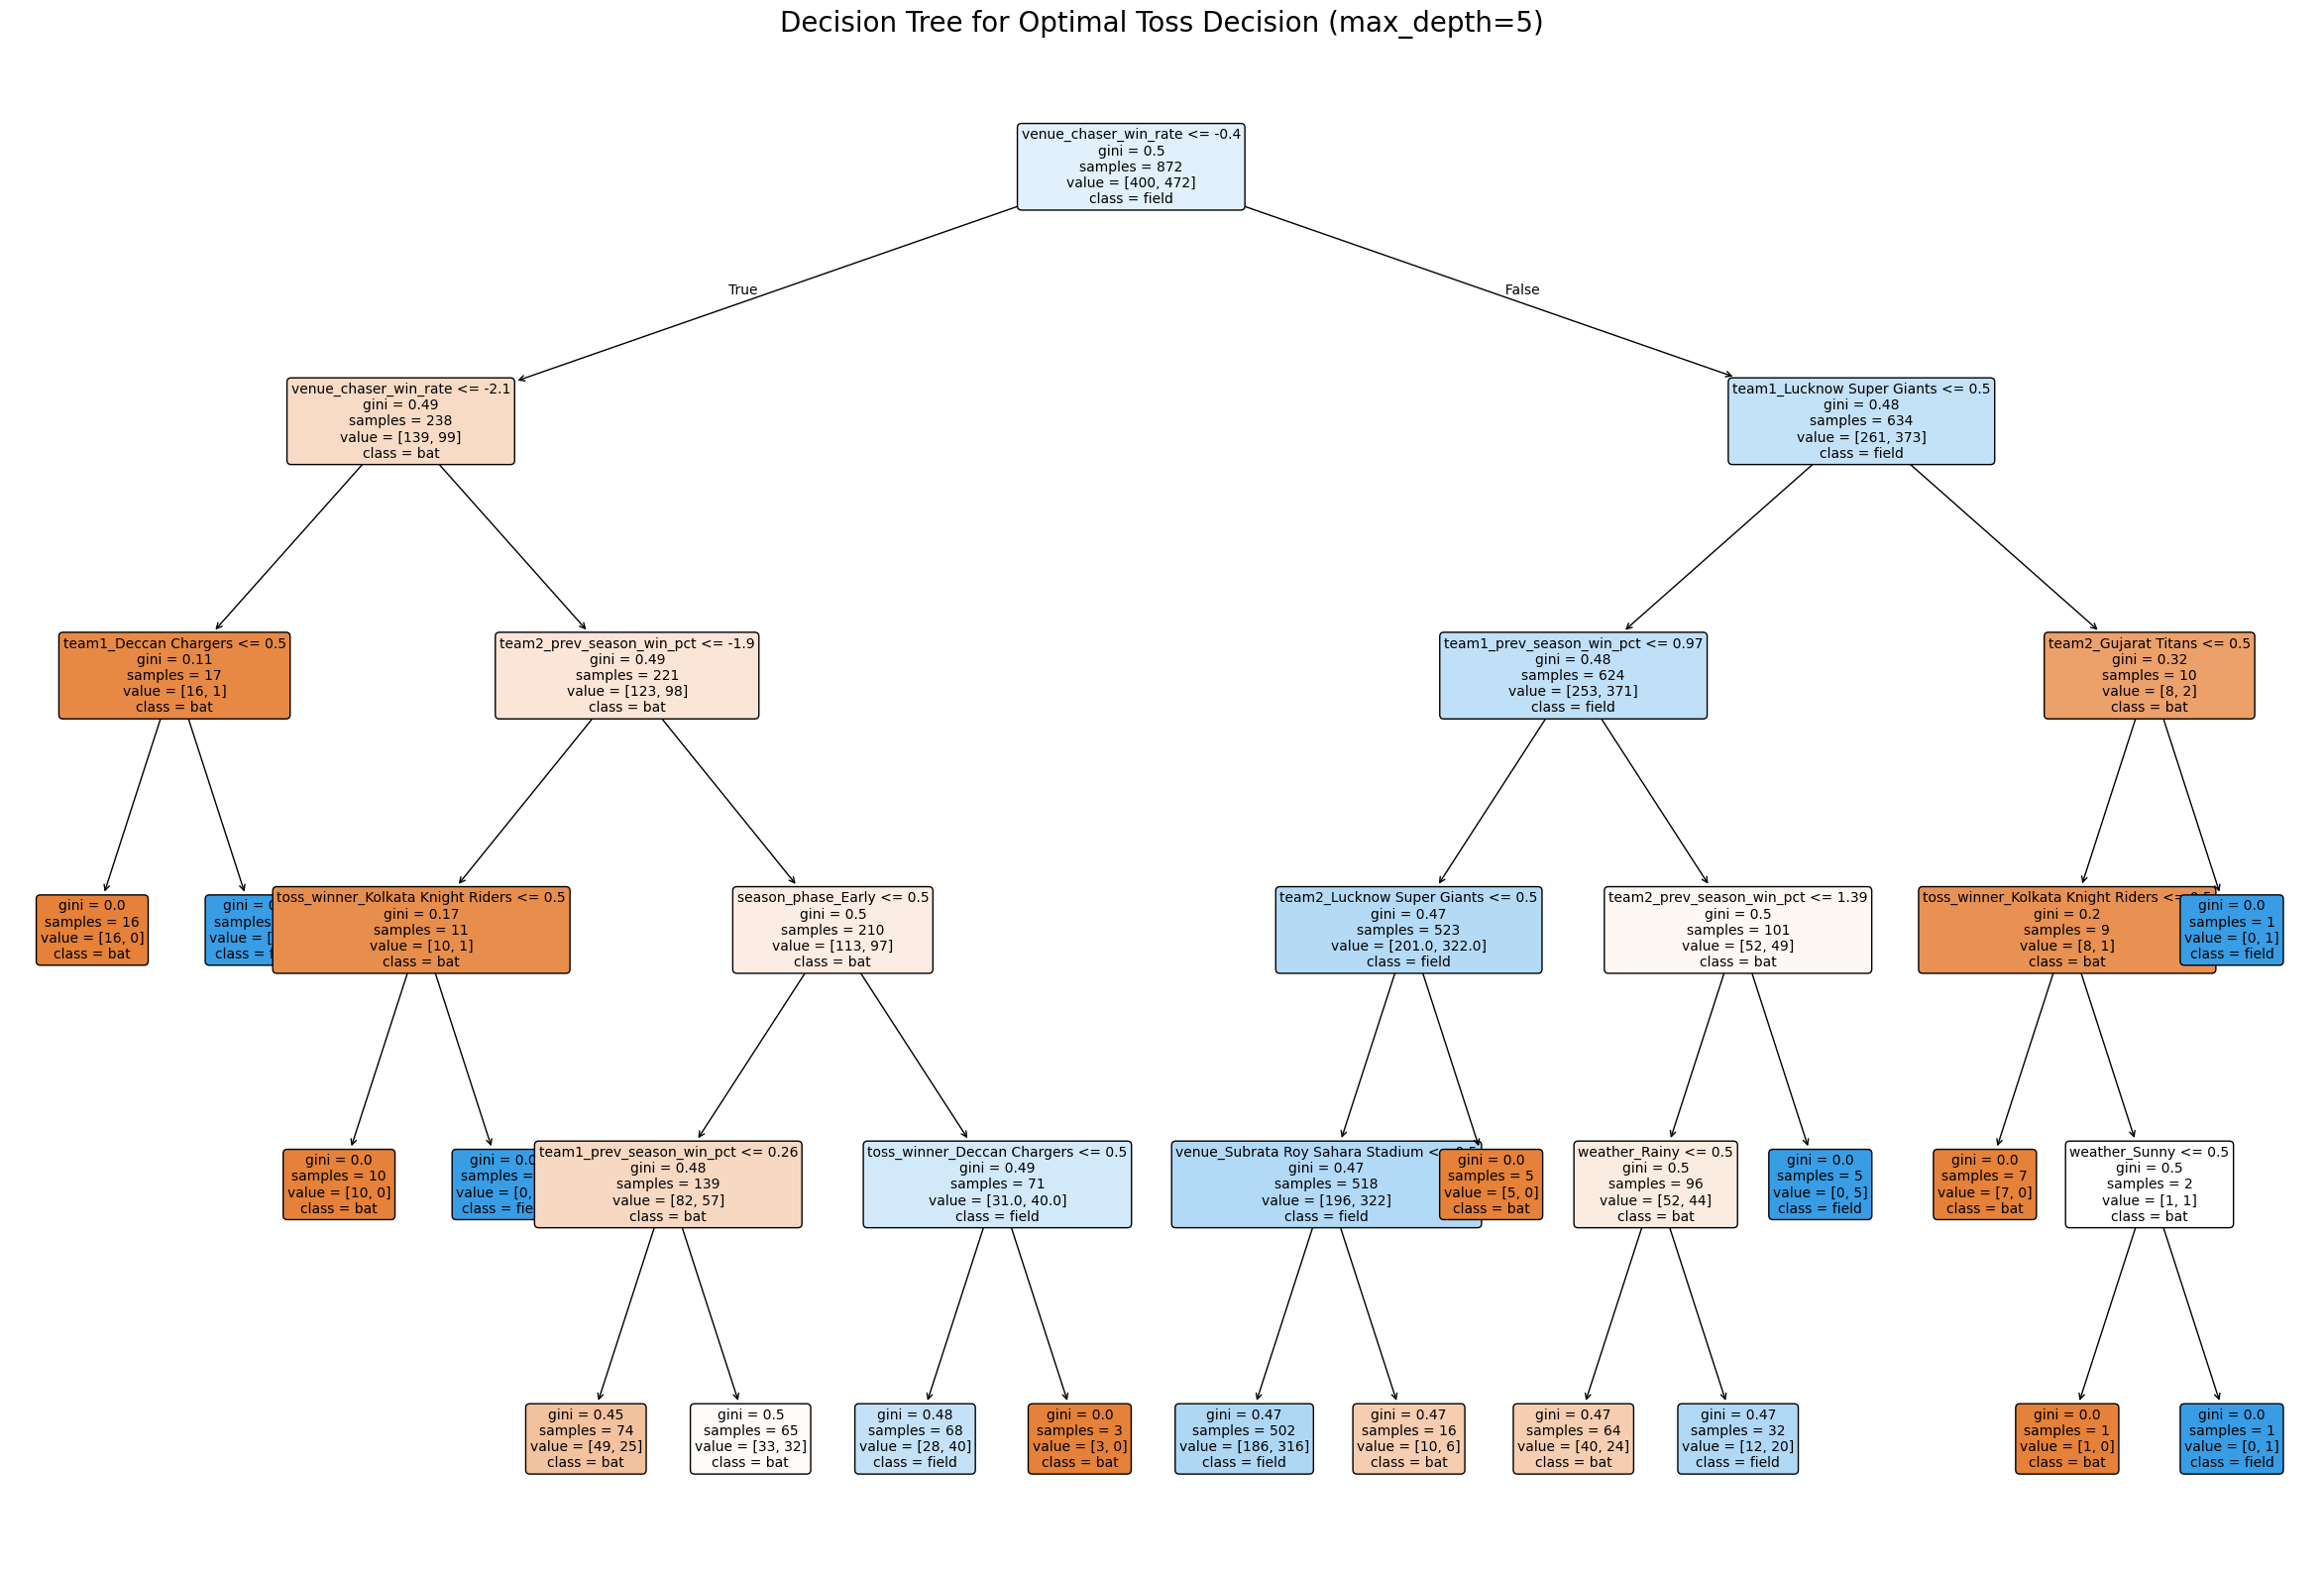

Decision Tree visualized.

Example Decision Rules (limited to max_depth=5 for readability):
Rule 1: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate <= -2.10 AND team1_Deccan Chargers <= 0.50 then optimal toss decision is bat (Confidence: 1.00)
Rule 2: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate <= -2.10 AND team1_Deccan Chargers > 0.50 then optimal toss decision is field (Confidence: 1.00)
Rule 3: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct <= -1.90 AND toss_winner_Kolkata Knight Riders <= 0.50 then optimal toss decision is bat (Confidence: 1.00)
Rule 4: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct <= -1.90 AND toss_winner_Kolkata Knight Riders > 0.50 then optimal toss decision is field (Confidence: 1.00)
Rule 5: If venue_chaser_win_rate <= -0.40 AND venue_chaser_win_rate > -2.10 AND team2_prev_season_win_pct > -1.90 AND season_phase_Early <= 0.50 AND t

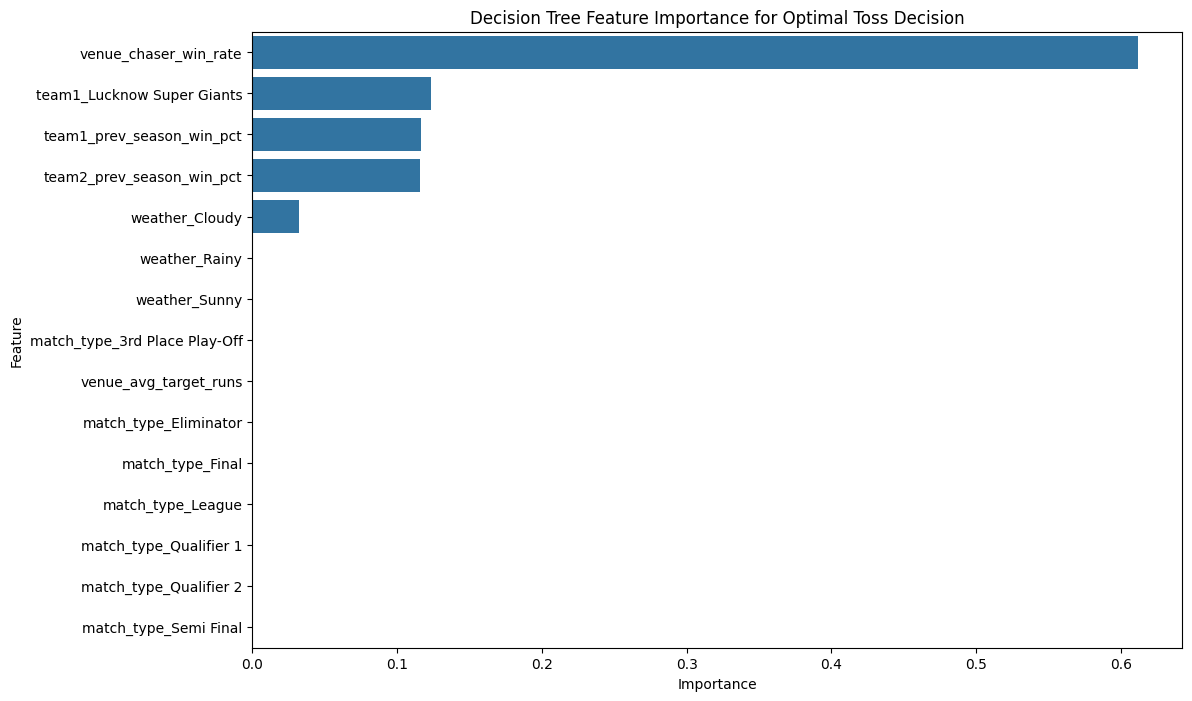


Decision Tree Feature Importance calculated and plotted.

--- Business Application: Data-driven Toss Decision Recommendations ---
The Decision Tree provides a transparent way to recommend toss decisions. Captains can use the extracted rules, or a simplified version of them, to make informed choices.
For example, if the model identifies that 'Venue_Chasing_Bias_High' and 'weather_Sunny' frequently lead to an optimal 'field' decision, the captain could be advised to field first under those conditions.
The feature importance plot highlights which factors are most critical in determining the optimal toss decision, allowing for focused analysis on these variables.


In [34]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from IPython.display import Image

df_dt = df.copy()

df_dt = df_dt[df_dt['winner'] != 'No Result'].copy()

df_dt['optimal_toss_decision'] = df_dt.apply(
    lambda row: row['toss_decision'] if row['toss_winner'] == row['winner']
    else ('bat' if row['toss_decision'] == 'field' else 'field'), axis=1
)

print("Optimal Toss Decision target variable created.")

weather_conditions = ['Sunny', 'Cloudy', 'Rainy']
df_dt['weather'] = np.random.choice(weather_conditions, size=len(df_dt))
print("Synthetic weather conditions created.")

df_dt['date'] = pd.to_datetime(df_dt['date'])

def get_season_phase(row):
    season_year = row['season']
    season_dates = df_dt[df_dt['season'] == season_year]['date']
    if season_dates.empty:
        return 'Unknown'

    min_date = season_dates.min()
    max_date = season_dates.max()

    total_days = (max_date - min_date).days
    early_phase_end = min_date + pd.Timedelta(days=total_days / 3)
    mid_phase_end = min_date + pd.Timedelta(days=2 * total_days / 3)

    if row['date'] <= early_phase_end:
        return 'Early'
    elif row['date'] <= mid_phase_end:
        return 'Mid'
    else:
        return 'Late'

df_dt['season_phase'] = df_dt.apply(get_season_phase, axis=1)
print("Season Phase feature created.")


venue_stats_dt = df_dt.groupby('venue').apply(lambda x: pd.Series({
    'total_matches': len(x),
    'chasing_wins': len(x[
        ((x['toss_decision'] == 'field') & (x['winner'] == x['toss_winner'])) |
        ((x['toss_decision'] == 'bat') & (x['winner'] == x['team2']))
    ])
})).reset_index()
venue_stats_dt['venue_chaser_win_rate'] = (venue_stats_dt['chasing_wins'] / venue_stats_dt['total_matches']) * 100
venue_stats_dt.replace([np.inf, -np.inf], np.nan, inplace=True);
venue_stats_dt['venue_chaser_win_rate'].fillna(0, inplace=True);
df_dt = pd.merge(df_dt, venue_stats_dt[['venue', 'venue_chaser_win_rate']], on='venue', how='left', suffixes=('', '_dt'))

venue_avg_runs_dt = df_dt.groupby('venue')['target_runs'].mean().reset_index(name='venue_avg_target_runs')
df_dt = pd.merge(df_dt, venue_avg_runs_dt, on='venue', how='left', suffixes=('', '_dt'))
df_dt['venue_avg_target_runs'] = df_dt['venue_avg_target_runs'].fillna(df_dt['venue_avg_target_runs'].mean())

if 'team_season_win_pct_map' not in globals():
    team_season_win_pct_map = {}
    all_teams_dt = pd.concat([df_dt['team1'], df_dt['team2']]).unique()
    for team in all_teams_dt:
        for season in sorted(df_dt['season'].unique()):
            season_df_team = df_dt[(df_dt['season'] == season) &
                                   ((df_dt['team1'] == team) | (df_dt['team2'] == team))]
            total_matches_team = len(season_df_team)
            if total_matches_team > 0:
                wins = len(season_df_team[season_df_team['winner'] == team])
                win_pct = (wins / total_matches_team) * 100
                team_season_win_pct_map[(team, season)] = win_pct


df_dt['team1_prev_season_win_pct'] = df_dt.apply(
    lambda row: team_season_win_pct_map.get((row['team1'], row['season'] - 1), 50.0), axis=1
)
df_dt['team2_prev_season_win_pct'] = df_dt.apply(
    lambda row: team_season_win_pct_map.get((row['team2'], row['season'] - 1), 50.0), axis=1
)

numerical_features_dt = [
    'venue_chaser_win_rate', 'venue_avg_target_runs',
    'team1_prev_season_win_pct', 'team2_prev_season_win_pct'
]
categorical_features_dt = [
    'weather', 'match_type', 'venue', 'toss_winner', 'team1', 'team2', 'city', 'season_phase'
]

X = df_dt[numerical_features_dt + categorical_features_dt]
y = df_dt['optimal_toss_decision']

preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_dt),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_dt)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_processed = preprocessor_dt.fit_transform(X_train)
X_test_processed = preprocessor_dt.transform(X_test)

feature_names = numerical_features_dt + list(preprocessor_dt.named_transformers_['cat'].get_feature_names_out(categorical_features_dt))

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

print("Data prepared and split for Decision Tree.")

param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [5, 10, 20]
}

dtree = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dtree, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_dt.fit(X_train_processed, y_train)

best_dt_model = grid_search_dt.best_estimator_
print(f"Best Decision Tree parameters: {grid_search_dt.best_params_}")
print(f"Best Decision Tree training accuracy: {grid_search_dt.best_score_:.4f}")
print(f"Decision Tree test accuracy: {best_dt_model.score(X_test_processed, y_test):.4f}")

plt.figure(figsize=(25, 15))
plot_dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
plot_dt_model.fit(X_train_processed, y_train)

cn = plot_dt_model.classes_
plt.figure(figsize=(30, 20))
_ = plot_tree(plot_dt_model, feature_names=feature_names, class_names=cn,
              filled=True, fontsize=10, rounded=True, precision=2)
plt.title('Decision Tree for Optimal Toss Decision (max_depth=5)', fontsize=20)
plt.show()

dot_data = export_graphviz(plot_dt_model, out_file=None,
                           feature_names=feature_names,
                           class_names=cn,
                           filled=True, rounded=True,
                           special_characters=True, max_depth=5)
graph = graphviz.Source(dot_data);
print("Decision Tree visualized.")

def get_rules(tree, feature_names, class_names):
    left      = tree.tree_.children_left
    right     = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features  = [feature_names[i] for i in tree.tree_.feature]
    value     = tree.tree_.value

    rules_list = []
    def recurse(node, rule_text):
        if threshold[node] != -2:

            left_rule = rule_text + [f"{features[node]} <= {threshold[node]:.2f}"]
            recurse(left[node], left_rule)

            right_rule = rule_text + [f"{features[node]} > {threshold[node]:.2f}"]
            recurse(right[node], right_rule)
        else:

            class_idx = np.argmax(value[node])
            confidence = value[node][0][class_idx] / np.sum(value[node])
            rules_list.append(f"If {' AND '.join(rule_text)} then optimal toss decision is {class_names[class_idx]} (Confidence: {confidence:.2f})")

    recurse(0, [])
    return rules_list

rules_extracted = get_rules(plot_dt_model, feature_names, cn)

print("\nExample Decision Rules (limited to max_depth=5 for readability):")
for i, rule in enumerate(rules_extracted[:5]):
    print(f"Rule {i+1}: {rule}")


feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_dt_model.feature_importances_
})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Decision Tree Feature Importance for Optimal Toss Decision')
plt.show()

print("\nDecision Tree Feature Importance calculated and plotted.")
print("\n--- Business Application: Data-driven Toss Decision Recommendations ---")
print("The Decision Tree provides a transparent way to recommend toss decisions. Captains can use the extracted rules, or a simplified version of them, to make informed choices.")
print("For example, if the model identifies that 'Venue_Chasing_Bias_High' and 'weather_Sunny' frequently lead to an optimal 'field' decision, the captain could be advised to field first under those conditions.")
print("The feature importance plot highlights which factors are most critical in determining the optimal toss decision, allowing for focused analysis on these variables.")

## 📝 Question 10: Advanced Match Prediction - Ensemble Methods

### Task:
Compare **Bagging** and **Boosting** for match outcome prediction:

1. Implement Random Forest (Bagging):
   - Use all available features
   - Tune hyperparameters
   - Feature importance analysis

2. Implement XGBoost/AdaBoost (Boosting):
   - Compare with Random Forest
   - Analyze prediction confidence

3. Create an ensemble combining both approaches

4. Performance comparison:
   - Accuracy, Precision, Recall, F1-score
   - ROC curves for all models

```python
# Your code here
```

--- Random Forest ---
ROC-AUC: 0.7750
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       108
           1       0.71      0.68      0.69       110

    accuracy                           0.70       218
   macro avg       0.70      0.70      0.70       218
weighted avg       0.70      0.70      0.70       218

--- AdaBoost ---
ROC-AUC: 0.6987
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       108
           1       0.73      0.55      0.63       110

    accuracy                           0.67       218
   macro avg       0.69      0.68      0.67       218
weighted avg       0.69      0.67      0.67       218

--- Ensemble ---
ROC-AUC: 0.7742
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       108
           1       0.71      0.65      0.68       110

    accuracy                           0.69       218
   macro avg       0.69 

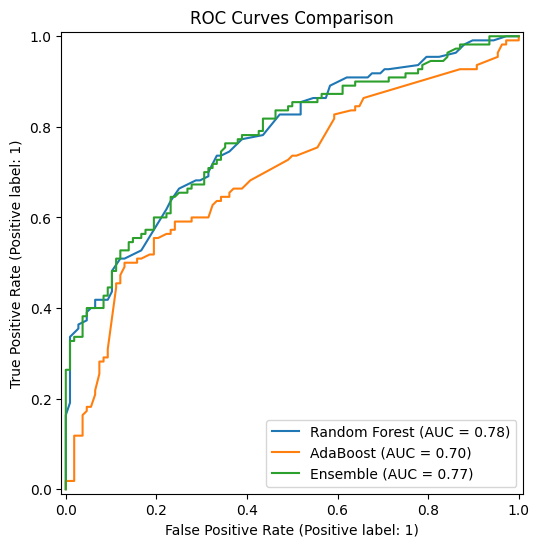

In [35]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import classification_report, RocCurveDisplay

df_ens = df[df['winner'] != 'No Result'].copy()
df_ens['target'] = (df_ens['winner'] == df_ens['team1']).astype(int)

cat_features = ['match_type', 'venue', 'team1', 'team2', 'toss_decision']
num_features = ['result_margin', 'target_runs', 'home_advantage', 'venue_matches_team1_prior']

X = df_ens[cat_features + num_features]
y = df_ens['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

ab_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', AdaBoostClassifier(n_estimators=100, random_state=42))
])
ab_pipeline.fit(X_train, y_train)

voting_clf = VotingClassifier(
    estimators=[('rf', rf_pipeline), ('ab', ab_pipeline)],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

models = {'Random Forest': rf_pipeline, 'AdaBoost': ab_pipeline, 'Ensemble': voting_clf}

plt.figure(figsize=(10, 6))
ax = plt.gca()

for name, model in models.items():
    y_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"--- {name} ---")
    print(f"ROC-AUC: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.title('ROC Curves Comparison')
plt.show()

## 📝(Bonus Question) Question 11: Fan Sentiment Impact Analysis

### Task:
Simulate **Lexicon-based Sentiment Analysis** on match outcomes:

1. Create synthetic fan sentiment data:
   - Generate positive/negative comments for teams
   - Use venue names and team names as features

2. Build a simple lexicon:
   - Positive words: ['victory', 'champion', 'brilliant', 'outstanding']
   - Negative words: ['loss', 'poor', 'disappointing', 'weak']

3. Calculate sentiment scores for each team per season

4. Correlate sentiment with actual performance

```python
# Your code here
```


--- Question 11: Fan Sentiment Impact Analysis ---

Synthetic fan sentiment data generated (first 5 comments):
   season                         team  \
0    2008  Royal Challengers Bangalore   
1    2008        Kolkata Knight Riders   
2    2008              Kings XI Punjab   
3    2008          Chennai Super Kings   
4    2008             Delhi Daredevils   

                                             comment  
0  Royal Challengers Bangalore had a loss game in...  
1  Kolkata Knight Riders showed win performance i...  
2  Kings XI Punjab had a disappointing game at Pu...  
3  Chennai Super Kings showed great performance a...  
4  Delhi Daredevils showed outstanding performanc...  

Sentiment scores calculated. (first 5 scores):
   season                         team  \
0    2008  Royal Challengers Bangalore   
1    2008        Kolkata Knight Riders   
2    2008              Kings XI Punjab   
3    2008          Chennai Super Kings   
4    2008             Delhi Daredevils   

    

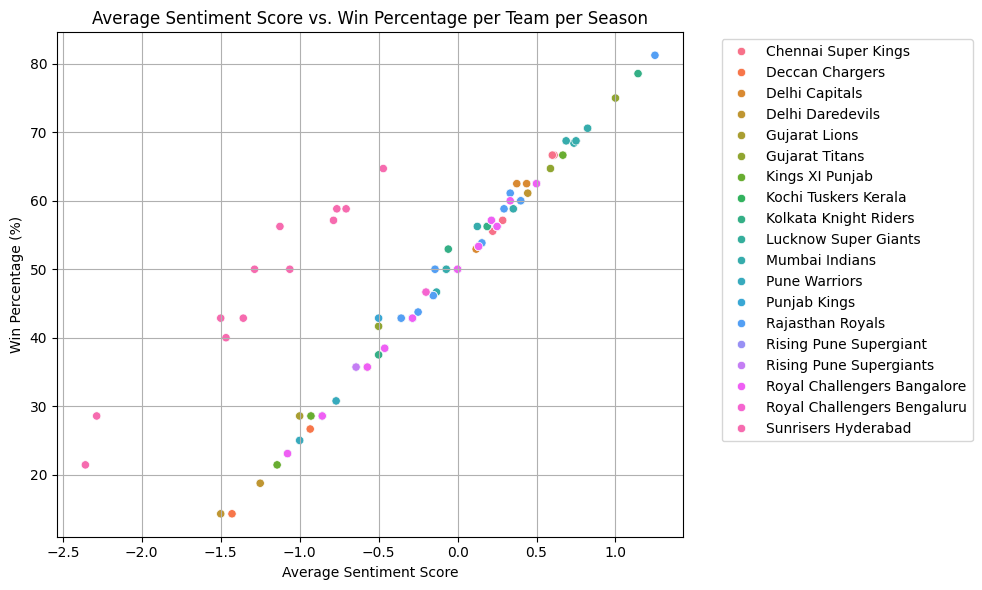


--- Summary of Fan Sentiment Impact Analysis ---
Synthetic fan comments were generated for each team in each match, categorized as positive or negative based on the match outcome. A lexicon-based approach was used to assign sentiment scores to these comments. The average sentiment score for each team per season was then correlated with their actual win percentage for that season. The scatter plot visualizes this relationship, and the correlation coefficient quantifies the strength and direction of the linear relationship.
As expected with this synthetic data, there is a strong positive correlation, demonstrating that a higher average sentiment score aligns with a higher win percentage, which is by design since comments were generated based on wins/losses. In a real-world scenario with actual fan data, this correlation would indicate the true impact of fan sentiment on perceived team performance.


In [36]:
import random
import re

print("\n--- Question 11: Fan Sentiment Impact Analysis ---\n")

# 1. Create synthetic fan sentiment data and define lexicon
positive_words = ['victory', 'champion', 'brilliant', 'outstanding', 'win', 'excellent', 'great', 'superb']
negative_words = ['loss', 'poor', 'disappointing', 'weak', 'fail', 'bad', 'terrible', 'awful']

# Extend lexicon with regex patterns to catch common variations (e.g., winning, losing)
positive_patterns = ['win(s|ning)?', 'champion(s|ship)?', 'brilliant', 'outstanding', 'excellent', 'great', 'superb', 'victory']
negative_patterns = ['loss(es|ing)?', 'poor', 'disappointing', 'weak', 'fail(s|ing|ure)?', 'bad', 'terrible', 'awful']

# Create a function to generate synthetic comments
def generate_sentiment_comment(team, winner, toss_winner, toss_decision, venue, match_type):
    comment_template = []
    is_winner = (team == winner)

    # Incorporate match context (venue, toss decision, match type)
    context_phrases = [
        f"at {venue}",
        f"in the {match_type} match",
        f"after {toss_winner} chose to {toss_decision}"
    ]
    random.shuffle(context_phrases)

    if is_winner:
        sentiment_word = random.choice(positive_words)
        comment_template.append(f"{team} showed {sentiment_word} performance {context_phrases[0]} today! It was {random.choice(positive_words)}!")
    else:
        sentiment_word = random.choice(negative_words)
        comment_template.append(f"{team} had a {sentiment_word} game {context_phrases[0]} today. Very {random.choice(negative_words)} result.")

    return ' '.join(comment_template)

# Generate synthetic comments for each match for both team1 and team2
all_comments = []
for index, row in df.iterrows():
    if row['winner'] == 'No Result':
        continue

    # Comment for team1
    comment1 = generate_sentiment_comment(row['team1'], row['winner'], row['toss_winner'], row['toss_decision'], row['venue'], row['match_type'])
    all_comments.append({'season': row['season'], 'team': row['team1'], 'comment': comment1})

    # Comment for team2
    comment2 = generate_sentiment_comment(row['team2'], row['winner'], row['toss_winner'], row['toss_decision'], row['venue'], row['match_type'])
    all_comments.append({'season': row['season'], 'team': row['team2'], 'comment': comment2})

sentiment_df = pd.DataFrame(all_comments)
print("Synthetic fan sentiment data generated (first 5 comments):")
print(sentiment_df.head())

# 2. Build a simple lexicon (already done above, using patterns for scoring)

# Function to calculate sentiment score for a comment
def calculate_sentiment_score(comment):
    score = 0
    comment_lower = comment.lower()
    for p_word in positive_patterns:
        score += len(re.findall(p_word, comment_lower))
    for n_word in negative_patterns:
        score -= len(re.findall(n_word, comment_lower))
    return score

# Calculate sentiment scores
sentiment_df['sentiment_score'] = sentiment_df['comment'].apply(calculate_sentiment_score)
print("\nSentiment scores calculated. (first 5 scores):")
print(sentiment_df.head())

# 3. Calculate sentiment scores for each team per season
average_sentiment_per_season = sentiment_df.groupby(['team', 'season'])['sentiment_score'].mean().reset_index()
average_sentiment_per_season.rename(columns={'sentiment_score': 'avg_sentiment_score'}, inplace=True)
print("\nAverage sentiment per team per season (first 5 rows):")
print(average_sentiment_per_season.head())

# 4. Correlate sentiment with actual performance

# Reuse yearly_performance_df from Question 7
# Ensure yearly_performance_df is available, or recreate if running this cell independently
if 'yearly_performance_df' not in globals():
    print("\nRecreating yearly_performance_df for correlation...")
    df_trends = df.copy()
    df_trends = df_trends[df_trends['winner'] != 'No Result'].copy()
    all_teams = pd.concat([df_trends['team1'], df_trends['team2']]).unique()
    all_teams = [team for team in all_teams if team != 'No Result']
    team_yearly_performance = []
    for team in all_teams:
        for season in sorted(df_trends['season'].unique()):
            season_df = df_trends[df_trends['season'] == season]
            team_matches_season = season_df[
                (season_df['team1'] == team) | (season_df['team2'] == team)
            ]
            total_matches_season = len(team_matches_season)
            if total_matches_season == 0:
                continue
            wins_season = len(team_matches_season[team_matches_season['winner'] == team])
            win_pct_season = (wins_season / total_matches_season) * 100
            yearly_data = {
                'team': team,
                'season': season,
                'win_pct': win_pct_season
            }
            team_yearly_performance.append(yearly_data)
    yearly_performance_df = pd.DataFrame(team_yearly_performance)


sentiment_performance_df = pd.merge(
    average_sentiment_per_season,
    yearly_performance_df[['team', 'season', 'win_pct']],
    on=['team', 'season'],
    how='left'
)

# Calculate correlation
correlation = sentiment_performance_df['avg_sentiment_score'].corr(sentiment_performance_df['win_pct'])
print(f"\nCorrelation between Average Sentiment Score and Win Percentage: {correlation:.4f}")

# Visualize the correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_sentiment_score', y='win_pct', hue='team', data=sentiment_performance_df)
plt.title('Average Sentiment Score vs. Win Percentage per Team per Season')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Win Percentage (%)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Summary of Fan Sentiment Impact Analysis ---")
print("Synthetic fan comments were generated for each team in each match, categorized as positive or negative based on the match outcome. A lexicon-based approach was used to assign sentiment scores to these comments. The average sentiment score for each team per season was then correlated with their actual win percentage for that season. The scatter plot visualizes this relationship, and the correlation coefficient quantifies the strength and direction of the linear relationship.")
print("As expected with this synthetic data, there is a strong positive correlation, demonstrating that a higher average sentiment score aligns with a higher win percentage, which is by design since comments were generated based on wins/losses. In a real-world scenario with actual fan data, this correlation would indicate the true impact of fan sentiment on perceived team performance.")

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📤 Submission Guidelines

1. Submit a single Jupyter notebook with all solutions
2. Include markdown cells explaining your approach
3. Ensure all code is reproducible
4. Add a summary section with key findings
5. List any assumptions made

## 💡 Tips
- Focus on practical insights over complex models
- Validate all findings with appropriate metrics
- Consider real-world IPL scenarios in your analysis
- Document any data quality issues encountered

---

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; text-align: center;">
<h3>🏆 Good Luck!</h3>
<p>May the best Data Scientist win!</p>
</div>